# 📐 Linear Algebra: the MODEL Box
## Foundations for AI &amp; ML — Notebook 2 of 4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)
![No installs](https://img.shields.io/badge/installs-none%20needed-brightgreen.svg)
![Level](https://img.shields.io/badge/level-zero%20to%20hero-orange.svg)

---
<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### A matrix is not a grid of numbers. It is a function that moves space.

Most of us were taught matrix multiplication as a procedure: line up a row, multiply term by term, add, write the number down, move to the next row. You can execute that perfectly and understand nothing.

One change of view fixes it. **A matrix is an active verb, not a static noun.** Feed it a vector and it hands back a vector that has been stretched, rotated, sheared, or flattened. Once you see that, the arithmetic stops being a chore and becomes a picture — and the determinant, invertibility and eigenvectors all fall out of it as consequences rather than as new rules to memorise.

In Notebook 1 we wrote `ŷ = w·x + b` and moved on. This notebook opens that expression up.


</div>

## 🎯 What You Will Be Able to Do

By the end of this notebook you will be able to:

1. **Read a matrix as a transformation** — and say where the basis vectors land just by looking at its columns.
2. **Compute a matrix-vector product two ways** — the row-dot-product rule and the weighted-sum-of-columns view — and explain why they must agree.
3. **Recognise the four things a 2×2 matrix can do**: scale, rotate, shear, and collapse.
4. **Explain the dot product** as a 1×n transformation that flattens space onto a line, and read its **sign** as alignment.
5. **Say why raw dot products mislead** and when to use cosine similarity instead — with a worked example where the bigger dot product is the worse match.
6. **Predict the dimension change from a matrix's shape**, and explain why *shape is a promise but rank is the reality*.
7. **Define the determinant geometrically** as a signed area (or volume) factor, and derive $ad - bc$ from that picture.
8. **State the chain of equivalences** linking $\det = 0$, singularity, linear dependence, collapse, and the null space — and know they are one fact, not five.
9. **Find eigenvalues and eigenvectors by hand** via the characteristic equation, and explain what $\lambda = 0$, $1$, $-1$ mean geometrically.
10. **Explain PCA in one sentence** using the eigenvectors of a covariance matrix — and run it on real data.

## 📚 Table of Contents

| Part | Topic | What it unlocks | Level |
|---|---|---|---|
| **1 · A Matrix Moves Space** | columns as landing spots | Every matrix, read at a glance | ⭐⭐ |
| **2 · The Dot Product** | projection, alignment, a neuron | What `w·x` actually computes | ⭐⭐ |
| **3 · Changing Dimension** | 3-D, shape, rank, null space | What a network layer really does | ⭐⭐⭐ |
| **4 · The Determinant** | signed area factor | One number that says "reversible?" | ⭐⭐⭐ |
| **5 · Invertibility & Collapse** | the chain of equivalences | Why regression solvers fail | ⭐⭐⭐ |
| **6 · Eigenvectors** | the axes a matrix is built around | PCA, covariance, stability | ⭐⭐⭐⭐ |
| **7 · Capstone** | a layer, and PCA on real data | The MODEL box, assembled | ⭐⭐⭐⭐ |

## 🗺️ The Series — Four Notebooks, One Machine

This is one of four notebooks that together cover the whole of **Foundations for AI & ML**. They are built around the book's own organising idea: every model that learns runs the same four-beat loop, and each notebook owns one beat.

| | Notebook | File |
|---|---|---|
| 🧭 **1** | *The Learning Machine* | `foundations_1_the_learning_machine.ipynb` |
| 📐 **2** | *Linear Algebra: the MODEL* | `foundations_2_linear_algebra.ipynb` ← **you are here** |
| 🎲 **3** | *Probability: the DATA* | `foundations_3_probability.ipynb` |
| 📉 **4** | *Calculus: LOSS & UPDATE* | `foundations_4_calculus.ipynb` |

```
        ┌──────────┐   ┌──────────┐   ┌──────────┐   ┌──────────┐
  ──►   │   DATA   │──►│  MODEL   │──►│   LOSS   │──►│  UPDATE  │──┐
        └──────────┘   └──────────┘   └──────────┘   └──────────┘  │
         notebook 3     notebook 2     notebook 4     notebook 4   │
         probability   linear algebra   calculus       calculus    │
              ▲                                                    │
              └────────────────── repeat ◄─────────────────────────┘
```

Notebook 1 (this series' opening) builds the loop itself, end to end, so the other three always have somewhere to plug in.


## 🗺️ How to Read This

Same five beats as the rest of the series: 🧠 **Intuition** → 📐 **The Maths** → 💻 **Code** → 📊 **Picture** → ✅ **Takeaway**.
Also: ⚠️ a trap · ✍️ do it by hand · 🔗 a link to another notebook.

**One promise:** no formula in this notebook is dropped from the sky. Every one is built from a picture first, and then checked in code — usually against NumPy, sometimes against a by-hand calculation we do together.

## ⏱️ Time

**About 2 hours** carefully; 30 minutes to skim. Parts 1, 2 and 6 are the load-bearing ones.


## ⚙️ Setup — Run This First

One cell, no installs. It pins the random seed (so every number you see matches the text), sets the plotting style, and defines the **five colours** this whole series uses to mean the same five things.

| Colour | Means |
|---|---|
| 🔵 blue | **data** — what we are given |
| 🟣 purple | **model** — parameters, transformations |
| 🟠 orange | **prediction** — what the model says |
| 🟢 green | **truth** — the right answer |
| 🔴 red | **error** — the gap we are closing |


In [1]:
# ============================================================
#  Setup — the toolkit and the house style for this series
# ============================================================
# Everything here is pre-installed on Colab. Nothing to download.
import sys, math, json, textwrap, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Polygon
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

# ---- reproducibility -------------------------------------------------
SEED = 7
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ---- the colour grammar, used identically in all four notebooks ------
# Learn these five and every figure in the series reads at a glance.
C_DATA  = "#2563EB"   # blue    — data, inputs, what we are given
C_MODEL = "#7C3AED"   # purple  — the model, parameters, transformations
C_PRED  = "#EA7317"   # orange  — predictions, what the model says
C_TRUE  = "#15803D"   # green   — ground truth, the target, the right answer
C_ERR   = "#DC2626"   # red     — error, loss, the gap we are closing
C_GREY  = "#64748B"   # slate   — structure, axes, annotation
C_SOFT  = "#F1F5F9"   # near-white fill

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": C_GREY,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "legend.frameon": True,
    "legend.framealpha": 0.92,
    "figure.facecolor": "white",
})

print("Toolkit ready.")
print(f"NumPy {np.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"Random seed pinned to {SEED} — your numbers will match the text exactly.")


Toolkit ready.
NumPy 2.1.3 | Matplotlib 3.10.0
Random seed pinned to 7 — your numbers will match the text exactly.


In [2]:
# ============================================================
#  Drawing helpers — used by every figure in the series
# ============================================================
# Read these once. After this cell, every diagram is three lines.

def box(ax, x, y, w, h, text, fc=C_SOFT, ec=C_GREY, fs=10, tc="#0F172A",
        lw=1.8, bold=False, alpha=1.0):
    """A rounded label box centred on (x, y). Returns its centre."""
    ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h,
                                boxstyle="round,pad=0.02,rounding_size=0.08",
                                fc=fc, ec=ec, lw=lw, zorder=2, alpha=alpha))
    ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=tc,
            zorder=3, fontweight="bold" if bold else "normal", linespacing=1.4)
    return (x, y)

def arrow(ax, p0, p1, color=C_GREY, rad=0.0, lw=2.0, label=None, ls="-",
          label_off=(0, 0.12), fs=9, style="-|>", ms=16):
    """A (optionally curved, optionally labelled) arrow from p0 to p1."""
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle=style, mutation_scale=ms,
                                 color=color, lw=lw, linestyle=ls, zorder=1,
                                 connectionstyle=f"arc3,rad={rad}",
                                 shrinkA=7, shrinkB=9))
    if label:
        mx, my = (p0[0] + p1[0]) / 2, (p0[1] + p1[1]) / 2
        ax.text(mx + label_off[0], my + label_off[1], label, ha="center",
                va="center", fontsize=fs, color=color, style="italic",
                bbox=dict(fc="white", ec="none", alpha=0.88, pad=1.6), zorder=4)

def stage(ax, xlim=(0, 10), ylim=(0, 6), title=None):
    """Turn an Axes into a blank drawing stage."""
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.axis("off")
    if title:
        ax.set_title(title, pad=12)
    return ax

def tidy(ax, xlabel=None, ylabel=None, title=None, legend=False):
    """Consistent finishing touches for a plotted (non-diagram) Axes."""
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title:  ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    if legend: ax.legend(fontsize=9)
    return ax

print("Drawing helpers ready: box(), arrow(), stage(), tidy()")


Drawing helpers ready: box(), arrow(), stage(), tidy()


### One more toolkit cell — drawing transformations

Everything in Parts 1–5 is a picture of *what a matrix does to the plane*. This cell defines the two helpers that draw those pictures: a grid of lines, and the basis vectors $\hat{\imath}$ and $\hat{\jmath}$ as arrows.

Read it once; after this, every transformation figure is three lines of code.


In [3]:
# ============================================================
#  The transformation-drawing kit (used by Parts 1-6)
# ============================================================
# The idea: build a grid of straight lines, push every point of every line
# through a matrix, and redraw. Because the transformation is LINEAR, the
# lines stay straight and evenly spaced -- so the picture tells the whole story.

def grid_lines(limit=3, n=61, samples=60):
    """Return a list of (x, y) polylines forming a square grid.

    We build the SOURCE grid over a generously wide range (3x the window we
    display) and sample it finely. A transformation that stretches space
    spreads the lines apart, so a coarse source grid would leave the picture
    looking empty -- this way the visible frame stays filled whether the
    matrix expands or contracts.
    """
    span  = limit * 3
    ticks = np.linspace(-span, span, n)
    fine  = np.linspace(-span, span, samples)
    lines = []
    for t in ticks:
        lines.append(np.c_[fine, np.full_like(fine, t)])   # horizontal
        lines.append(np.c_[np.full_like(fine, t), fine])   # vertical
    return lines

def draw_transform(ax, A, limit=3, title=None, show_basis=True,
                   show_unit_square=True, grid_color=None):
    """Draw the grid AFTER applying the 2x2 matrix A, plus the landed basis vectors."""
    A = np.asarray(A, dtype=float)
    gc = grid_color or C_GREY

    # ── the transformed grid ──
    for line in grid_lines(limit):
        out = line @ A.T                       # apply A to every point on the line
        ax.plot(out[:, 0], out[:, 1], color=gc, lw=0.9, alpha=0.45, zorder=1)

    # ── the unit square, carried along ──
    if show_unit_square:
        square = np.array([[0, 0], [1, 0], [1, 1], [0, 1]], float)
        ax.add_patch(Polygon(square @ A.T, closed=True, fc=C_MODEL,
                             ec=C_MODEL, alpha=0.20, lw=2, zorder=2))

    # ── where the basis vectors landed = the COLUMNS of A ──
    if show_basis:
        for vec, col, name in [(A[:, 0], C_DATA, r"$\hat{\imath}$"),
                               (A[:, 1], C_PRED, r"$\hat{\jmath}$")]:
            ax.annotate("", xy=vec, xytext=(0, 0),
                        arrowprops=dict(arrowstyle="-|>", color=col, lw=3,
                                        mutation_scale=18), zorder=5)
            ax.text(vec[0] * 1.12 + 0.08, vec[1] * 1.12 + 0.08, name,
                    color=col, fontsize=14, fontweight="bold", zorder=6)

    ax.axhline(0, color="#334155", lw=1.1, zorder=3)
    ax.axvline(0, color="#334155", lw=1.1, zorder=3)
    ax.set_aspect("equal")
    ax.set_xlim(-limit, limit); ax.set_ylim(-limit, limit)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if title:
        ax.set_title(title, fontsize=11)
    return ax

print("Transformation kit ready: grid_lines(), draw_transform()")
print("Blue arrow = where î  landed   ·   Orange arrow = where ĵ  landed")


Transformation kit ready: grid_lines(), draw_transform()
Blue arrow = where î  landed   ·   Orange arrow = where ĵ  landed


# Part 1 · A Matrix Moves Space ⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### The rule, stated once — so we can leave it behind

For an $m \times n$ matrix $A$ and a vector $\mathbf{x}$, the product $A\mathbf{x}$ is a new vector whose $i$-th entry is row $i$ of $A$ dotted with $\mathbf{x}$:

$$ (A\mathbf{x})_i \;=\; \sum_j A_{ij}\, x_j $$

That is correct, it is what your computer does, and it explains nothing. For the rest of this Part we rely on the *meaning* instead.


</div>

## 1.1 One Concrete Multiplication

$$ A = \begin{bmatrix} 2 & 0 \\ 0 & 3 \end{bmatrix}, \qquad \mathbf{x} = \begin{bmatrix} 3 \\ 1 \end{bmatrix} $$

Row one dotted with $\mathbf{x}$: $\;2 \cdot 3 + 0 \cdot 1 = 6$.
Row two dotted with $\mathbf{x}$: $\;0 \cdot 3 + 3 \cdot 1 = 3$.

So $A\mathbf{x} = [6, 3]$. The point $(3,1)$ **moved** to $(6,3)$: its $x$-coordinate doubled and its $y$-coordinate tripled.

Now apply that to *every* point in the plane at once and you have stretched all of space — twice as wide, three times as tall. **That** is what the matrix is.

## 1.2 The One Trick: Watch the Basis Vectors

Instead of tracking some arbitrary point, track the two special vectors that build every other vector:

- $\hat{\imath} = [1, 0]$ — one unit step along $x$
- $\hat{\jmath} = [0, 1]$ — one unit step along $y$

Every vector is a recipe in terms of these two. The point $(3, 1)$ *means* $3\hat{\imath} + 1\hat{\jmath}$.

Now feed $\hat{\imath}$ through $A$:

$$ A \cdot [1, 0] = [2 \cdot 1 + 0 \cdot 0,\; 0 \cdot 1 + 3 \cdot 0] = [2, 0] $$

That is **exactly the first column of $A$**. And $\hat{\jmath}$:

$$ A \cdot [0, 1] = [2 \cdot 0 + 0 \cdot 1,\; 0 \cdot 0 + 3 \cdot 1] = [0, 3] $$

**Exactly the second column.**

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 The single most useful fact in linear algebra

**The columns of a matrix are the landing spots of the basis vectors.**

Column one is the new home of $\hat{\imath}$. Column two is the new home of $\hat{\jmath}$. Once you know where those two go, you know where **every** point goes — because a linear transformation keeps the grid straight and evenly spaced, so everything else just rides along.

</div>


In [4]:
# ============================================================
#  The columns ARE the landing spots — checked, not asserted
# ============================================================
A = np.array([[2.0, 0.0],
              [0.0, 3.0]])

i_hat = np.array([1.0, 0.0])
j_hat = np.array([0.0, 1.0])

print("Where do the basis vectors land?")
print("=" * 52)
print(f"  A @ î  = {A @ i_hat}     first  column of A = {A[:, 0]}")
print(f"  A @ ĵ  = {A @ j_hat}     second column of A = {A[:, 1]}")
print(f"\n  identical? {np.allclose(A @ i_hat, A[:, 0]) and np.allclose(A @ j_hat, A[:, 1])}")

x = np.array([3.0, 1.0])
print()
print("And an arbitrary point, two ways:")
print("=" * 52)
print(f"  row-dot-product rule       A @ x           = {A @ x}")
print(f"  weighted sum of columns    3·col1 + 1·col2 = {3 * A[:, 0] + 1 * A[:, 1]}")
print()
print("  Same answer, because they are the same operation seen from two sides.")


Where do the basis vectors land?
  A @ î  = [2. 0.]     first  column of A = [2. 0.]
  A @ ĵ  = [0. 3.]     second column of A = [0. 3.]

  identical? True

And an arbitrary point, two ways:
  row-dot-product rule       A @ x           = [6. 3.]
  weighted sum of columns    3·col1 + 1·col2 = [6. 3.]

  Same answer, because they are the same operation seen from two sides.


## 1.3 Why Multiplication Suddenly Feels Obvious

Because $\mathbf{x} = 3\hat{\imath} + 1\hat{\jmath}$, and because the transformation preserves addition and scaling, the output *must* be

$$ A\mathbf{x} = 3 \cdot (\text{where } \hat{\imath} \text{ lands}) + 1 \cdot (\text{where } \hat{\jmath} \text{ lands}) = 3[2,0] + 1[0,3] = [6,3] $$

Same answer as the row rule — but now it carries meaning:

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Matrix-vector multiplication is a **weighted sum of the matrix's columns**, where the weights are the entries of $\mathbf{x}$.

The row-dot-product recipe and the column-combination recipe are two views of one operation. The row view is how you compute it; **the column view is how you understand it.**

</div>


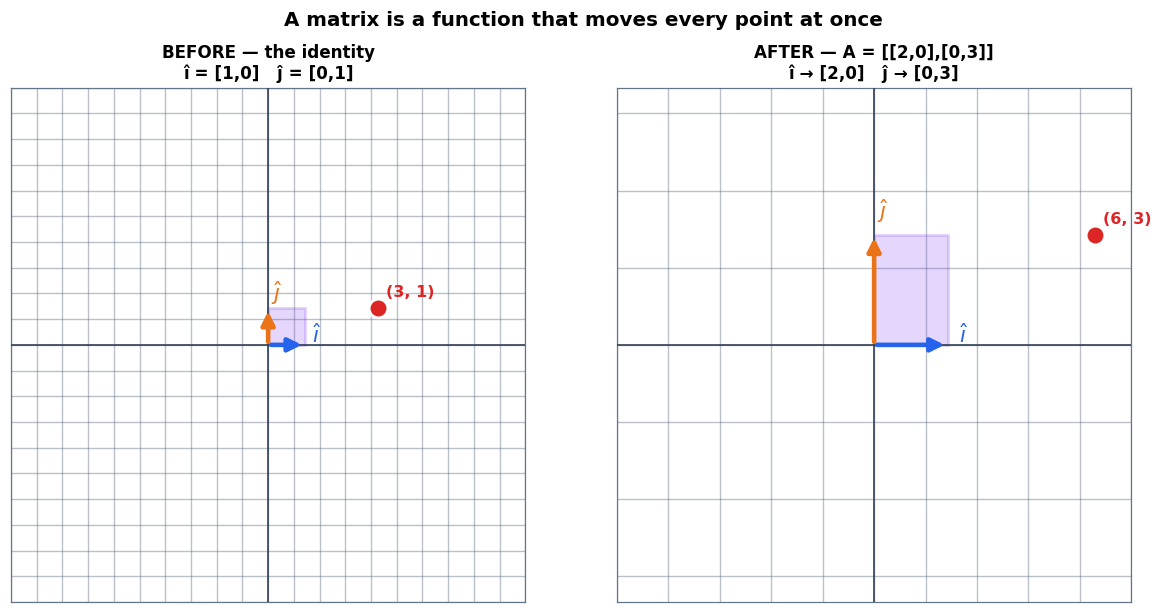

In [5]:
# ============================================================
#  Figure: the same grid, before and after
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 5.6))

# BOTH panels use the SAME window, so the growth is honestly visible
draw_transform(axes[0], np.eye(2), limit=7.0,
               title="BEFORE — the identity\nî = [1,0]   ĵ = [0,1]")
draw_transform(axes[1], A, limit=7.0,
               title="AFTER — A = [[2,0],[0,3]]\nî → [2,0]   ĵ → [0,3]")

# follow one specific point through the transformation
for ax, pt in [(axes[0], x), (axes[1], A @ x)]:
    ax.scatter(*pt, s=150, color=C_ERR, zorder=7, edgecolor="white", lw=1.8)
    ax.text(pt[0] + 0.22, pt[1] + 0.32, f"({pt[0]:.0f}, {pt[1]:.0f})",
            color=C_ERR, fontsize=10.5, fontweight="bold", zorder=8)

fig.suptitle("A matrix is a function that moves every point at once",
             fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left is the plane doing nothing** — the identity matrix. The blue arrow is $\hat{\imath}$ at $[1,0]$, the orange arrow is $\hat{\jmath}$ at $[0,1]$, and the shaded purple square is the **unit square** they span. Its area is 1.

**Right is the same plane after $A$ acted on it.** Three things to notice, in order:

1. **The blue arrow now ends at $[2,0]$ and the orange at $[0,3]$** — which are precisely the two columns of $A$. This is the fact from 1.2, drawn.
2. **The grid is still made of straight, evenly spaced, parallel lines.** Nothing bent. That is what *linear* means, and it is why knowing two arrows is enough to know the whole picture.
3. **The red dot rode along.** It started at $(3,1)$ and landed at $(6,3)$ — the arithmetic we did by hand, happening geometrically.

**What to look for:** the purple square became a $2 \times 3$ rectangle. Its area went from 1 to 6. Hold on to that number — in Part 4 it turns out to have a name.

**The common misread:** the grid on the right is not "a different grid drawn on the same plane." It *is* the original grid, carried to new positions. Every intersection you see is the image of an intersection on the left.


</div>

## 1.4 Four Matrices, Four Ways to Move Space

Different matrices do different things, and you can read the action **straight off the columns**. Here are the four that cover almost everything, each applied to the same corner point $[1,1]$.

| Matrix | Columns say | Effect | $[1,1]$ lands at |
|---|---|---|---|
| $\begin{bmatrix}2&0\\0&3\end{bmatrix}$ | $\hat{\imath}\to[2,0]$, $\hat{\jmath}\to[0,3]$ | **scale** — stretch $x$ by 2, $y$ by 3 | $[2,3]$ |
| $\begin{bmatrix}0&-1\\1&0\end{bmatrix}$ | $\hat{\imath}\to[0,1]$, $\hat{\jmath}\to[-1,0]$ | **rotate** 90° anticlockwise | $[-1,1]$ |
| $\begin{bmatrix}1&1\\0&1\end{bmatrix}$ | $\hat{\imath}\to[1,0]$, $\hat{\jmath}\to[1,1]$ | **shear** — slant like a pushed deck of cards | $[2,1]$ |
| $\begin{bmatrix}1&2\\2&4\end{bmatrix}$ | $\hat{\imath}\to[1,2]$, $\hat{\jmath}\to[2,4]$ | **collapse** — flatten the plane onto a line | on the line |

The last one is different in kind, and it is the one this notebook is really about. Notice that its second column is exactly **twice** the first.


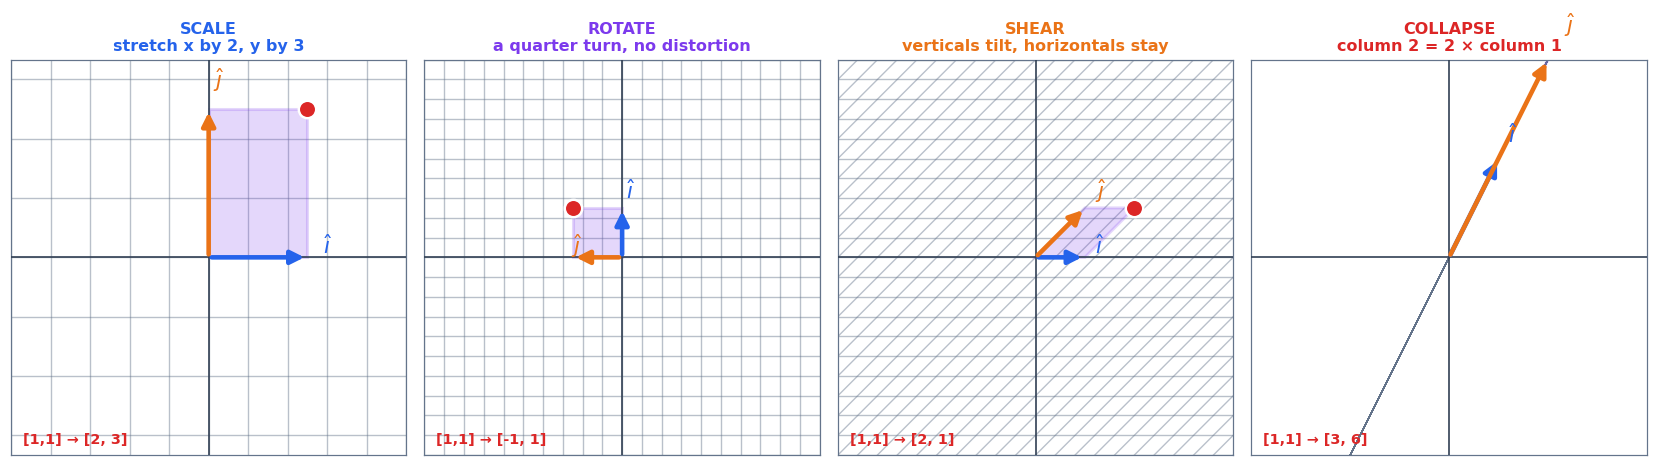

The corner [1,1] under each transformation:
   SCALE     -> [2.0, 3.0]
   ROTATE    -> [-1.0, 1.0]
   SHEAR     -> [2.0, 1.0]
   COLLAPSE  -> [3.0, 6.0]


In [6]:
# ============================================================
#  Figure: scale, rotate, shear, collapse
# ============================================================
transforms = [
    (np.array([[2., 0.], [0., 3.]]),  "SCALE",    "stretch x by 2, y by 3",      C_DATA),
    (np.array([[0., -1.], [1., 0.]]), "ROTATE",   "a quarter turn, no distortion", C_MODEL),
    (np.array([[1., 1.], [0., 1.]]),  "SHEAR",    "verticals tilt, horizontals stay", C_PRED),
    (np.array([[1., 2.], [2., 4.]]),  "COLLAPSE", "column 2 = 2 × column 1",      C_ERR),
]

fig, axes = plt.subplots(1, 4, figsize=(15.2, 4.3))
corner = np.array([1.0, 1.0])
for ax, (M, name, sub, col) in zip(axes, transforms):
    draw_transform(ax, M, limit=4, title=f"{name}\n{sub}")
    landed = M @ corner
    ax.scatter(*landed, s=130, color=C_ERR, zorder=8, edgecolor="white", lw=1.6)
    ax.text(0.03, 0.03, f"[1,1] → [{landed[0]:.0f}, {landed[1]:.0f}]",
            transform=ax.transAxes, fontsize=9.4, color=C_ERR, fontweight="bold")
    ax.set_title(f"{name}\n{sub}", fontsize=10.5, color=col)

plt.tight_layout(); plt.show()

print("The corner [1,1] under each transformation:")
for M, name, _, _ in transforms:
    print(f"   {name:<9} -> {(M @ corner).round(2).tolist()}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Four matrices, one input point, four fates.** In every panel the blue and orange arrows are the columns of that matrix, and the shaded square is the unit square carried along.

**Scale** pulls the grid apart along the axes. The square becomes a rectangle; both arrows stay perpendicular.

**Rotate** turns the whole plane a quarter-turn. Look closely: the square is still a *square*, and the arrows are still perpendicular and still length 1. A rotation preserves every length and every angle — the shape is rigidly turned, never distorted.

**Shear** leaves $\hat{\imath}$ exactly where it was and slides $\hat{\jmath}$ sideways. Vertical lines tilt; horizontal lines do not move. The square becomes a leaning parallelogram — and, worth noticing now, one with the *same area*.

**Collapse is the important one.** Both arrows lie along the *same line*, because the second column is exactly twice the first. There is nowhere in the plane for any output to be except on that single line. The shaded square has been squashed to a sliver with **no area at all**.

**What to look for:** in the first three panels the two arrows enclose some genuine area; in the fourth they enclose none. That difference — whether the columns point in independent directions or fall in line — is the whole subject of Parts 4 and 5.

**The common misread:** collapse is not a rare pathological case. It is what happens whenever one column carries no information the others did not already have — which, in a data matrix, means whenever two features are redundant. We will see exactly that failure in Part 5.


</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Why collapse is permanent

When the columns fall along one line, the transformation is **singular**: it maps 2-D into 1-D and can never be run backwards, because infinitely many input points get crushed onto each output point.

You cannot tell whether a shadow came from a hand or a bird. The flattening destroyed the information — no cleverness recovers it.

</div>

## 1.5 When the Matrix Is Not Square

Everything so far used $2 \times 2$ matrices, which keep vectors inside the plane. But "columns are landing spots" works for **any** shape — and a rectangular matrix *changes the dimension* of the space.

$$ B = \begin{bmatrix} 1 & 0 & 2 \\ 0 & 1 & 1 \end{bmatrix}, \qquad \mathbf{x} = \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix} $$

$B$ has **three** columns — one landing spot for each of the three input basis vectors — and every landing spot lives in the **2-D** output plane. Read it with the column view: the entries of $\mathbf{x}$ are the weights $1, 2, 3$, so

$$ B\mathbf{x} = 1[1,0] + 2[0,1] + 3[2,1] = [1,0] + [0,2] + [6,3] = [7,5] $$

A three-number input became a two-number output. **Information was thrown away** — many different 3-D vectors map to $[7,5]$.

🔗 *This is exactly what a neural network layer does. A layer mapping a 784-pixel image to 10 class scores is one $10 \times 784$ matrix performing this same weighted sum.*


In [7]:
# ============================================================
#  A non-square matrix changes the dimension
# ============================================================
B = np.array([[1.0, 0.0, 2.0],
              [0.0, 1.0, 1.0]])          # 2x3: maps R³ -> R²
x3 = np.array([1.0, 2.0, 3.0])

print(f"B has shape {B.shape}  ->  it maps R^{B.shape[1]} to R^{B.shape[0]}")
print(f"  B @ x = {B @ x3}")
print(f"  weighted columns: 1·{B[:,0]} + 2·{B[:,1]} + 3·{B[:,2]} = {1*B[:,0] + 2*B[:,1] + 3*B[:,2]}")
print()

# Information really is destroyed: find another input with the same output
x3_other = x3 + np.array([2.0, 1.0, -1.0])       # a direction B sends to zero
print("Two DIFFERENT 3-D inputs, one identical 2-D output:")
print(f"   B @ {x3.tolist()}       = {B @ x3}")
print(f"   B @ {x3_other.tolist()}  = {B @ x3_other}")
print(f"   inputs equal? {np.allclose(x3, x3_other)}    outputs equal? {np.allclose(B @ x3, B @ x3_other)}")
print()
print("Given only the output [7,5], you cannot say which input produced it.")
print("That is what 'losing a dimension' costs.")


B has shape (2, 3)  ->  it maps R^3 to R^2
  B @ x = [7. 5.]
  weighted columns: 1·[1. 0.] + 2·[0. 1.] + 3·[2. 1.] = [7. 5.]

Two DIFFERENT 3-D inputs, one identical 2-D output:
   B @ [1.0, 2.0, 3.0]       = [7. 5.]
   B @ [3.0, 3.0, 2.0]  = [7. 5.]
   inputs equal? False    outputs equal? True

Given only the output [7,5], you cannot say which input produced it.
That is what 'losing a dimension' costs.


## 1.6 Two Traps Worth Naming Now

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Trap 1 — the **columns** are the landing spots, not the rows

It is tempting to glance at the top row $[2, 0]$ and think that is where $\hat{\imath}$ goes. It is not. $\hat{\imath}$ lands on the **first column**, read *downward*. For a symmetric matrix the two happen to look alike and the confusion hides; for a rotation or a shear it gives you entirely the wrong picture.

### ⚠️ Trap 2 — order matters, and the vector goes on the right

$A\mathbf{x}$ (matrix left, vector right) is the transformation we have been drawing. For two matrices, $AB$ and $BA$ are usually **not equal**. And $A(B\mathbf{x})$ means *apply $B$ first, then $A$* — read right to left, like nested functions.

</div>


R @ S  (shear FIRST, then rotate):
[[ 0. -1.]
 [ 1.  1.]]

S @ R  (rotate FIRST, then shear):
[[ 1. -1.]
 [ 1.  0.]]

Equal? False


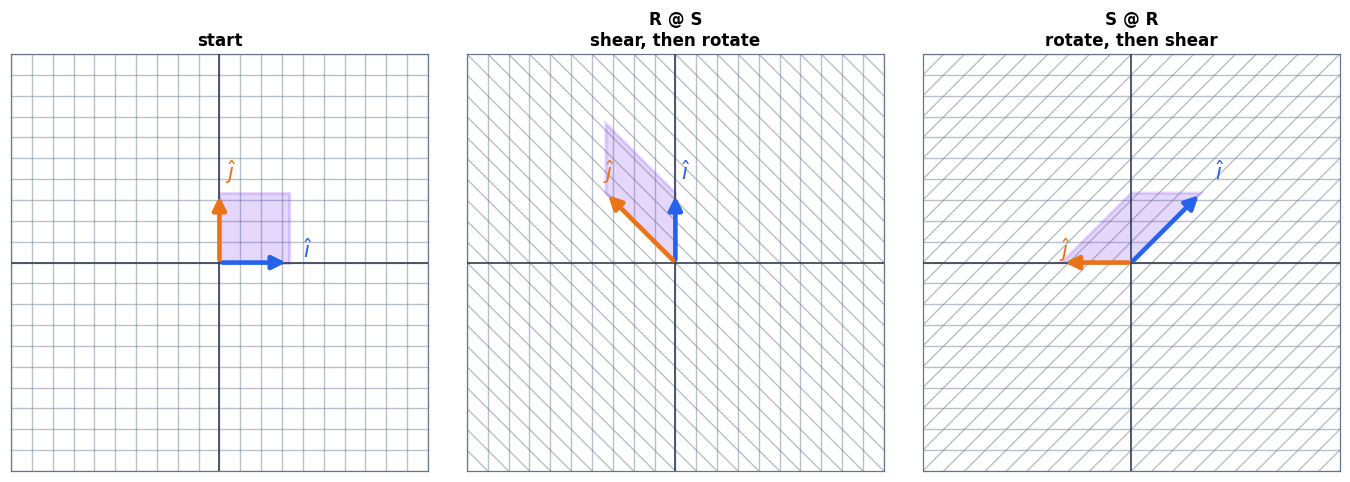

In [8]:
# ============================================================
#  Trap 2, demonstrated: rotate-then-shear ≠ shear-then-rotate
# ============================================================
R = np.array([[0., -1.], [1., 0.]])      # rotate 90°
S = np.array([[1., 1.], [0., 1.]])       # shear

print("R @ S  (shear FIRST, then rotate):")
print(R @ S)
print("\nS @ R  (rotate FIRST, then shear):")
print(S @ R)
print(f"\nEqual? {np.allclose(R @ S, S @ R)}")

fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.3))
draw_transform(axes[0], np.eye(2), limit=3, title="start")
draw_transform(axes[1], R @ S, limit=3, title="R @ S\nshear, then rotate")
draw_transform(axes[2], S @ R, limit=3, title="S @ R\nrotate, then shear")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**The same two operations, applied in the two possible orders, give visibly different planes.** Compare the middle and right panels: the shaded unit square leans in different directions and the arrows land in different places.

**Read the notation carefully.** In `R @ S` the matrix nearest the vector acts first, so $S$ (shear) happens first and $R$ (rotate) second. It reads right to left, exactly like nested function calls $R(S(\mathbf{x}))$ — because that is precisely what it is.

**What to look for:** in the middle panel the shear tilted the grid and *then* the whole tilted thing was turned. In the right panel the grid was turned first, so the shear afterwards pushes along a different direction entirely.

**Why this matters beyond geometry:** in a neural network, layers compose exactly like this. Swapping two layers is not a cosmetic change; it is a different function. Matrix multiplication being non-commutative is not a mathematical technicality — it is why the *order* of operations in a model is part of the model.


</div>

## 1.7 Part 1 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- **A matrix is a function on space**, not a grid of numbers. It moves every point at once while keeping grid lines straight, parallel and evenly spaced.
- **The columns are the landing spots of the basis vectors.** Column one is where $\hat{\imath}$ goes; column two is where $\hat{\jmath}$ goes. Knowing those two determines everything.
- **Multiplication is a weighted sum of the columns**, weighted by the entries of $\mathbf{x}$. Same answer as the row rule, far more meaning.
- Four things a $2\times2$ matrix can do: **scale, rotate, shear, collapse**. Only the last destroys information.
- **Shape determines dimension change**: an $m \times n$ matrix maps $\mathbb{R}^n \to \mathbb{R}^m$. Every neural network layer is exactly this.
- **Columns, not rows. Vector on the right. Rightmost matrix acts first.**

### ➡️ Next Up

There is one transformation so important it gets its own Part: the one that takes a whole vector and returns a **single number**.

</div>


# Part 2 · The Dot Product ⭐⭐

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### The simplest linear transformation of all — and the one your computer runs billions of times a second

Every neuron's $w \cdot x + b$. Every attention score $q \cdot k$. Every similarity lookup in a search index. All the same operation: **collapse a vector onto a line and report how far along it landed.**


</div>

## 2.1 Two Definitions That Look Nothing Alike

You are usually handed these on different days, and they look unrelated.

**The algebraic one** — pure bookkeeping:

$$ \mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i = a_1 b_1 + a_2 b_2 + \dots $$

**The geometric one** — no coordinates anywhere:

$$ \mathbf{a} \cdot \mathbf{b} = |\mathbf{a}|\,|\mathbf{b}|\cos\theta $$

Why on earth would *a sum of products of coordinates* equal *lengths times the cosine of an angle*? They do not even mention the same things.

The answer: they are two views of a single idea — **a linear transformation.**

## 2.2 A Dot Product Is a 1×n Matrix

Take $\mathbf{a} = [3, 4]$ and $\mathbf{x} = [2, 1]$. Algebraically, $\mathbf{a}\cdot\mathbf{x} = 6 + 4 = 10$. A whole two-dimensional arrow went in; **one number** came out.

Now write $\mathbf{a}$ lying down as a row and multiply:

$$ \begin{bmatrix} 3 & 4 \end{bmatrix} \begin{bmatrix} 2 \\ 1 \end{bmatrix} = 10 $$

That is a matrix-vector product: a $1 \times 2$ matrix times a $2 \times 1$ vector. And from Part 1, an $m \times n$ matrix maps $\mathbb{R}^n \to \mathbb{R}^m$ — so a $1 \times 2$ matrix maps $\mathbb{R}^2 \to \mathbb{R}^1$, **the number line**.

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 The dot product with a fixed vector **is** a linear transformation

It takes the whole plane and flattens it onto a line. The two definitions were never separate: the geometric one simply describes **what that particular flattening does**.

</div>


In [9]:
# ============================================================
#  The dot product, three ways — all the same number
# ============================================================
a = np.array([3.0, 4.0])
xv = np.array([2.0, 1.0])

algebraic = (a * xv).sum()
as_matrix = (a.reshape(1, 2) @ xv.reshape(2, 1)).item()
cos_theta = algebraic / (np.linalg.norm(a) * np.linalg.norm(xv))
geometric = np.linalg.norm(a) * np.linalg.norm(xv) * cos_theta

print("a =", a.tolist(), "   x =", xv.tolist())
print("=" * 56)
print(f"  algebraic   Σ aᵢxᵢ            = {algebraic:.4f}")
print(f"  as a matrix [3 4] @ [2;1]     = {as_matrix:.4f}")
print(f"  geometric   |a||x|cos θ       = {geometric:.4f}")
print(f"\n  angle between them: θ = {np.degrees(np.arccos(cos_theta)):.2f}°")
print()
print(f"  |a| = √(9+16) = {np.linalg.norm(a):.0f}   (a clean 3-4-5 triangle, chosen on purpose)")
print(f"  So the PROJECTION of x onto a's direction = {algebraic}/{np.linalg.norm(a):.0f} = "
      f"{algebraic / np.linalg.norm(a):.1f}")


a = [3.0, 4.0]    x = [2.0, 1.0]
  algebraic   Σ aᵢxᵢ            = 10.0000
  as a matrix [3 4] @ [2;1]     = 10.0000
  geometric   |a||x|cos θ       = 10.0000

  angle between them: θ = 26.57°

  |a| = √(9+16) = 5   (a clean 3-4-5 triangle, chosen on purpose)
  So the PROJECTION of x onto a's direction = 10.0/5 = 2.0


## 2.3 What the Single Number Means: a Shadow

The dot product collapses a vector to a number — but *which* number? Regroup the geometric form:

$$ \mathbf{a}\cdot\mathbf{x} = |\mathbf{a}| \cdot \underbrace{\left(|\mathbf{x}|\cos\theta\right)}_{\text{the shadow}} $$

The piece in brackets, $|\mathbf{x}|\cos\theta$, is exactly the length of the shadow $\mathbf{x}$ casts onto the direction of $\mathbf{a}$ — its **projection**. So:

$$ \mathbf{a}\cdot\mathbf{x} \;=\; \underbrace{|\mathbf{a}|}_{\text{scale}} \times \underbrace{(\text{projection of } \mathbf{x} \text{ onto } \mathbf{a})}_{\text{how far along } \mathbf{a}} $$

With our numbers: $|\mathbf{a}| = 5$ and $\mathbf{a}\cdot\mathbf{x} = 10$, so the projection is $10/5 = 2$. **A purely geometric fact, recovered from pure arithmetic.**


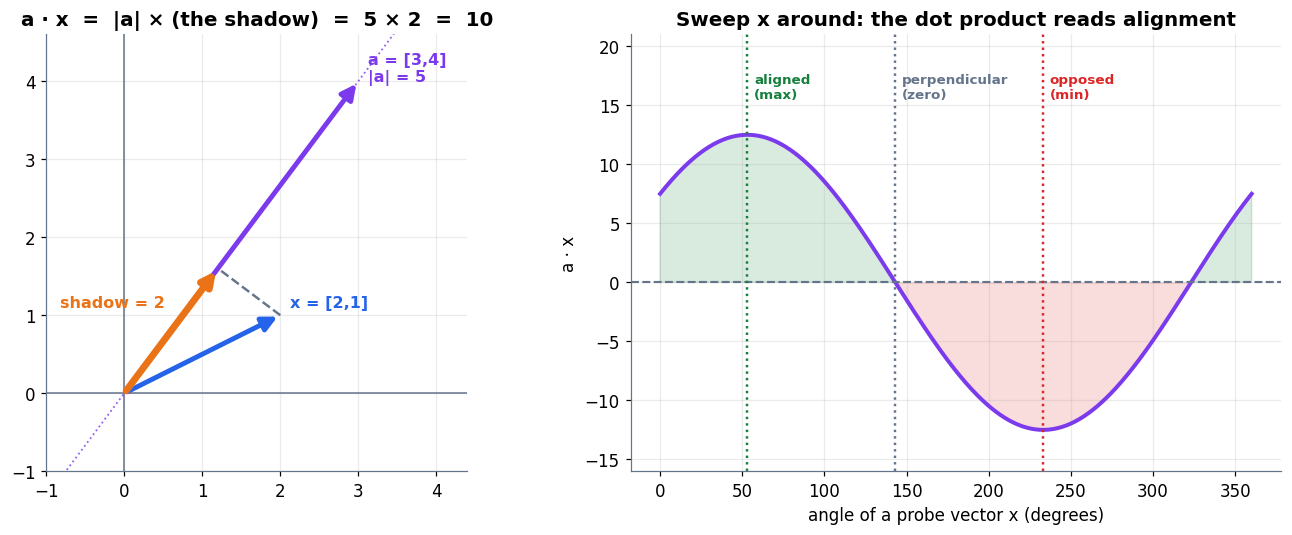

In [10]:
# ============================================================
#  Figure: the dot product as a shadow
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 5.0))

# ── left: the projection picture ──
a_hat = a / np.linalg.norm(a)
proj_len = algebraic / np.linalg.norm(a)
proj_pt = proj_len * a_hat

ax1.axhline(0, color=C_GREY, lw=1); ax1.axvline(0, color=C_GREY, lw=1)
# the line through a, extended
tt = np.linspace(-0.6, 1.25, 10)
ax1.plot(tt * a[0], tt * a[1], color=C_MODEL, lw=1.2, ls=":", alpha=0.8)
ax1.annotate("", xy=a, xytext=(0, 0),
             arrowprops=dict(arrowstyle="-|>", color=C_MODEL, lw=3.2, mutation_scale=20))
ax1.annotate("", xy=xv, xytext=(0, 0),
             arrowprops=dict(arrowstyle="-|>", color=C_DATA, lw=3.2, mutation_scale=20))
# the shadow
ax1.plot([xv[0], proj_pt[0]], [xv[1], proj_pt[1]], color=C_GREY, lw=1.6, ls="--")
ax1.annotate("", xy=proj_pt, xytext=(0, 0),
             arrowprops=dict(arrowstyle="-|>", color=C_PRED, lw=4.5, mutation_scale=18))
ax1.text(a[0] + 0.12, a[1], "a = [3,4]\n|a| = 5", color=C_MODEL, fontsize=10.5, fontweight="bold")
ax1.text(xv[0] + 0.12, xv[1] + 0.1, "x = [2,1]", color=C_DATA, fontsize=10.5, fontweight="bold")
ax1.text(proj_pt[0] * 0.5 - 0.75, proj_pt[1] * 0.5 + 0.30,
         f"shadow = {proj_len:.0f}", color=C_PRED, fontsize=10.5, fontweight="bold",
         ha="center")
ax1.set_xlim(-1, 4.4); ax1.set_ylim(-1, 4.6); ax1.set_aspect("equal")
tidy(ax1, None, None, "a · x  =  |a| × (the shadow)  =  5 × 2  =  10")

# ── right: sweeping x around, watching the dot product ──
angles = np.linspace(0, 2 * np.pi, 400)
probe = np.c_[np.cos(angles), np.sin(angles)] * 2.5
dots = probe @ a
ax2.plot(np.degrees(angles), dots, color=C_MODEL, lw=2.6)
ax2.axhline(0, color=C_GREY, lw=1.4, ls="--")
ax2.fill_between(np.degrees(angles), 0, dots, where=dots > 0, color=C_TRUE, alpha=0.16)
ax2.fill_between(np.degrees(angles), 0, dots, where=dots < 0, color=C_ERR, alpha=0.16)
theta_a = np.degrees(np.arctan2(a[1], a[0]))
for ang, lab, col in [(theta_a, "aligned\n(max)", C_TRUE),
                      (theta_a + 90, "perpendicular\n(zero)", C_GREY),
                      (theta_a + 180, "opposed\n(min)", C_ERR)]:
    ax2.axvline(ang % 360, color=col, ls=":", lw=1.6)
    ax2.text((ang % 360) + 4, 15.6, lab, color=col, fontsize=8.8, fontweight="bold")
ax2.set_ylim(-16, 21)
tidy(ax2, "angle of a probe vector x (degrees)", "a · x",
     "Sweep x around: the dot product reads alignment")

plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — the shadow, drawn.** The purple arrow is $\mathbf{a} = [3,4]$, with length exactly 5 (a 3-4-5 triangle, chosen so the arithmetic stays clean). The blue arrow is $\mathbf{x} = [2,1]$. Shine a light straight down onto the dotted line through $\mathbf{a}$: the grey dashed line is the light ray, and the thick orange arrow is the shadow $\mathbf{x}$ casts.

That shadow has length **2**. Multiply by $|\mathbf{a}| = 5$ and you get **10** — which is exactly what the algebraic recipe $3\cdot2 + 4\cdot1$ produced. Two definitions, one picture.

**Right — the same operation with $\mathbf{x}$ swept all the way around a circle.** The horizontal axis is the probe's angle; the vertical axis is the resulting dot product. Because $|\mathbf{a}|$ and $|\mathbf{x}|$ are fixed here, the *only* thing varying is $\cos\theta$ — and the curve is a clean cosine, which is the geometric definition made visible.

**Three positions are marked, and they are the three you must be able to feel:**
- **Aligned** — the probe points the same way as $\mathbf{a}$; the shadow is longest and the dot product is at its **maximum**.
- **Perpendicular** — the shadow has collapsed to a point; the dot product is **exactly zero**. This is the single most-used fact about dot products in all of machine learning.
- **Opposed** — the shadow points backwards along $\mathbf{a}$; the dot product goes **negative**.

**The common misread:** the green and red shading are not "good" and "bad". They are *agreement* and *disagreement* in direction. A large negative dot product is just as informative as a large positive one — it says the two vectors point firmly opposite ways.


</div>

## 2.4 The Pitfall: a Big Dot Product Does Not Mean "Very Aligned"

Here is where the dot product misleads people, and it matters enormously in practice.

Because $\mathbf{a}\cdot\mathbf{x} = |\mathbf{a}||\mathbf{x}|\cos\theta$, the number mixes **two different things**: how aligned the vectors are ($\cos\theta$) and how long they are ($|\mathbf{a}||\mathbf{x}|$). A large dot product might mean perfect alignment — or it might just mean one vector is enormous.

Watch it break with a query and two documents.


In [11]:
# ============================================================
#  When the bigger dot product is the WORSE match
# ============================================================
q  = np.array([1.0, 0.0])       # the query
d1 = np.array([1.0, 0.0])       # points exactly along the query
d2 = np.array([10.0, 1.0])      # tilted off-axis, but ten times longer

def cosine(u, v):
    return (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))

print(f"{'':<6}{'raw dot':>10}{'cosine':>10}{'angle':>10}")
print("-" * 38)
for name, d in [("d1", d1), ("d2", d2)]:
    ang = np.degrees(np.arccos(np.clip(cosine(q, d), -1, 1)))
    print(f"{name:<6}{q @ d:>10.2f}{cosine(q, d):>10.4f}{ang:>9.1f}°")
print("-" * 38)
print("Raw dot product says d2 wins by 10x.")
print("Cosine says d1 is a PERFECT match (angle 0°) and d2 is slightly off.")
print()
print("The raw dot product rewarded SIZE, not agreement.")
print("Cosine similarity divides the lengths out and compares direction alone:")
print("      cos θ = (a·x) / (|a| |x|)      always in [-1, 1]")


         raw dot    cosine     angle
--------------------------------------
d1          1.00    1.0000      0.0°
d2         10.00    0.9950      5.7°
--------------------------------------
Raw dot product says d2 wins by 10x.
Cosine says d1 is a PERFECT match (angle 0°) and d2 is slightly off.

The raw dot product rewarded SIZE, not agreement.
Cosine similarity divides the lengths out and compares direction alone:
      cos θ = (a·x) / (|a| |x|)      always in [-1, 1]


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Why every search index uses cosine similarity

`d2` looked twice as good only because it was ten times longer. Normalise both vectors to length 1 first — which is what cosine similarity does — and `d1` correctly wins.

This is exactly why retrieval systems compare **embeddings** with cosine similarity rather than raw dot products, and the same reason attention scores $q\cdot k$ are **scaled** before use. *The dot product measures alignment only once you have accounted for length; skip that and the longest vector wins by default.*

</div>

## 2.5 A Neuron Is One Dot Product

Now the payoff. A single artificial neuron computes

$$ z = \mathbf{w}\cdot\mathbf{x} + b $$

That is a dot product of a **learned weight vector** $\mathbf{w}$ with an input $\mathbf{x}$, plus a bias. Watch the collapse happen: the neuron takes a whole input vector and squashes it to **one number** $z$, which answers precisely one question —

> *how strongly does this input align with the pattern $\mathbf{w}$?*


In [12]:
# ============================================================
#  A neuron, in full: one dot product and a bias
# ============================================================
# Features of a suspicious email: [contains "free", number of links, is ALL CAPS]
feature_names = ["contains 'free'", "number of links", "is ALL CAPS"]
w_neuron = np.array([2.0, 0.5, 1.5])       # the LEARNED pattern
x_email  = np.array([1.0, 4.0, 0.0])       # this particular email

z = w_neuron @ x_email                      # or np.dot(w_neuron, x_email)

print("A single neuron weighing the evidence")
print("=" * 58)
print(f"{'feature':<20}{'w':>8}{'x':>8}{'contribution':>16}")
print("-" * 58)
for name, wi, xi in zip(feature_names, w_neuron, x_email):
    print(f"{name:<20}{wi:>8.1f}{xi:>8.1f}{wi * xi:>16.1f}")
print("-" * 58)
print(f"{'z = w · x':<20}{'':>16}{z:>16.1f}")
print()
print("'free' and the four links both pushed the score up.")
print("ALL CAPS contributed nothing — the feature was off (x = 0).")
print(f"The neuron collapsed a 3-D input to the single alignment score {z}.")
print()
print("Every neuron in every layer of every network does exactly this,")
print("at hardware speed, over vectors with hundreds or thousands of dimensions.")


A single neuron weighing the evidence
feature                    w       x    contribution
----------------------------------------------------------
contains 'free'          2.0     1.0             2.0
number of links          0.5     4.0             2.0
is ALL CAPS              1.5     0.0             0.0
----------------------------------------------------------
z = w · x                                        4.0

'free' and the four links both pushed the score up.
ALL CAPS contributed nothing — the feature was off (x = 0).
The neuron collapsed a 3-D input to the single alignment score 4.0.

Every neuron in every layer of every network does exactly this,
at hardware speed, over vectors with hundreds or thousands of dimensions.


## 2.6 Part 2 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- The dot product with a fixed vector is a **$1 \times n$ linear transformation**: it collapses all of $\mathbb{R}^n$ onto the number line.
- The number it returns is the **projection** of the input onto that vector, scaled by the vector's length: $\mathbf{a}\cdot\mathbf{x} = |\mathbf{a}| \times (\text{shadow})$.
- The **sign reads alignment**: positive = same direction, **zero = perpendicular**, negative = opposed. Zero is the most-used fact in the subject.
- $\mathbf{a}\cdot\mathbf{a} = |\mathbf{a}|^2$ — a vector is perfectly aligned with itself.
- ⚠️ A **big dot product does not mean well aligned** — it may just mean long. Divide out the lengths to get **cosine similarity**, which lives in $[-1, 1]$ and compares direction alone.
- **A neuron is one dot product plus a bias.** $\mathbf{w}$ is a learned pattern, and $z$ says how strongly the input matches it.

### ➡️ Next Up

We have seen a transformation that goes from $\mathbb{R}^2$ down to $\mathbb{R}^1$ — the most extreme dimension change there is. Part 3 widens the lens: 3-D, and what it really means to *lose* a dimension.

</div>


# Part 3 · Changing Dimension ⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### A matrix does not have to keep the dimension the same

It can lift 2-D into 3-D, flatten 3-D onto a plane, or crush a whole cube onto a line. **The shape of the matrix decides which** — and once you see that, an enormous amount of machine learning becomes straightforward bookkeeping.

The dot product already showed us the extreme case: a $1 \times n$ matrix squashing a whole vector to a single number. Now we generalise.


</div>

## 3.1 Three Dimensions: the Same Idea, One More Arrow

Everything carries over. In 3-D there are three basis vectors instead of two:

$$ \hat{\imath} = (1,0,0), \qquad \hat{\jmath} = (0,1,0), \qquad \hat{k} = (0,0,1) $$

A linear transformation still does exactly one thing worth remembering: **it decides where those basis vectors land**, and everything else rides the grid. So a 3-D transformation is fully described by three destination vectors, stacked as the columns of a $3\times3$ matrix.


In [13]:
# ============================================================
#  A 3x3 transformation: read the columns, predict the output
# ============================================================
A3 = np.array([[2.0, 0.0, 0.0],
               [0.0, 1.0, 0.0],
               [0.0, 0.0, 0.5]])       # stretch x, leave y, squash z
v3 = np.array([3.0, 4.0, 10.0])

print("The three columns say where the basis vectors land:")
print(f"   î  → {A3[:, 0]}")
print(f"   ĵ  → {A3[:, 1]}")
print(f"   k̂  → {A3[:, 2]}")
print()
print("So the point (3, 4, 10) must go to  3·col1 + 4·col2 + 10·col3 :")
print(f"   {3 * A3[:, 0]} + {4 * A3[:, 1]} + {10 * A3[:, 2]} = "
      f"{3 * A3[:, 0] + 4 * A3[:, 1] + 10 * A3[:, 2]}")
print(f"   NumPy agrees:  A3 @ v3 = {A3 @ v3}")
print()
print("The three landed arrows span a box (a parallelepiped).")
print(f"Its volume relative to the unit cube is 2 × 1 × 0.5 = {2 * 1 * 0.5}")
print("The cube got wider and flatter, but its VOLUME did not change.")
print("That number has a name, and it is the subject of Part 4.")


The three columns say where the basis vectors land:
   î  → [2. 0. 0.]
   ĵ  → [0. 1. 0.]
   k̂  → [0.  0.  0.5]

So the point (3, 4, 10) must go to  3·col1 + 4·col2 + 10·col3 :
   [6. 0. 0.] + [0. 4. 0.] + [0. 0. 5.] = [6. 4. 5.]
   NumPy agrees:  A3 @ v3 = [6. 4. 5.]

The three landed arrows span a box (a parallelepiped).
Its volume relative to the unit cube is 2 × 1 × 0.5 = 1.0
The cube got wider and flatter, but its VOLUME did not change.
That number has a name, and it is the subject of Part 4.


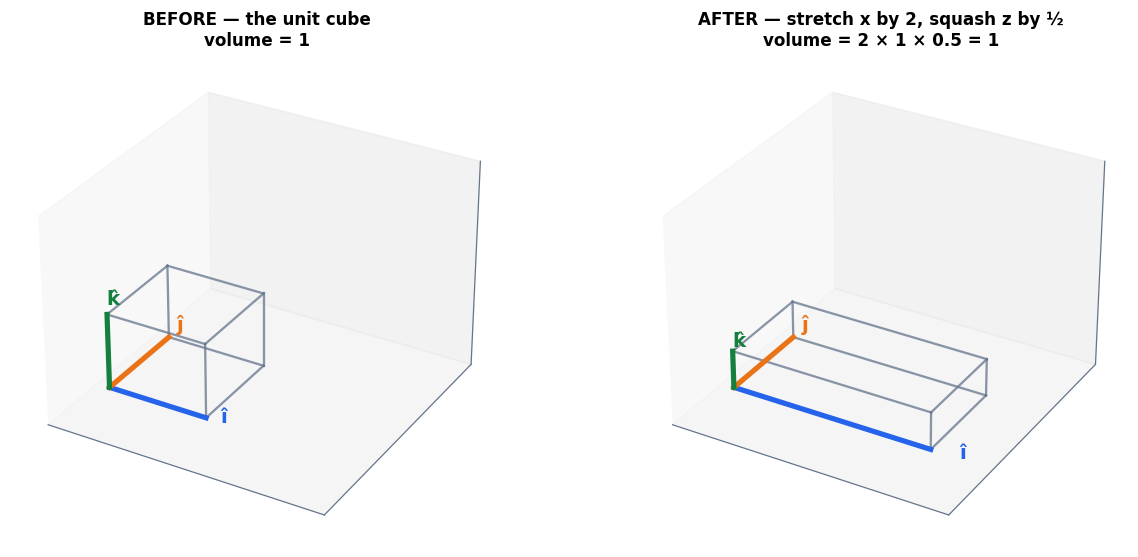

In [14]:
# ============================================================
#  Figure: the unit cube, before and after a 3-D transformation
# ============================================================
CUBE = np.array([[0,0,0],[1,0,0],[1,1,0],[0,1,0],
                 [0,0,1],[1,0,1],[1,1,1],[0,1,1]], float)
EDGES = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]

def draw_cube(ax, M, title, limit=2.4):
    pts = CUBE @ np.asarray(M, float).T
    for i, j in EDGES:
        ax.plot(*zip(pts[i], pts[j]), color=C_GREY, lw=1.5, alpha=0.75)
    for col, colr, name in [(0, C_DATA, "î"), (1, C_PRED, "ĵ"), (2, C_TRUE, "k̂")]:
        vec = np.asarray(M, float)[:, col]
        ax.plot(*zip([0, 0, 0], vec), color=colr, lw=3.4)
        ax.text(*(vec * 1.14), name, color=colr, fontsize=13, fontweight="bold")
    ax.set_xlim(-0.4, limit); ax.set_ylim(-0.4, limit); ax.set_zlim(-0.4, limit)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_title(title, fontsize=11)
    ax.grid(False)

fig = plt.figure(figsize=(11.6, 5.2))
ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")
draw_cube(ax1, np.eye(3), "BEFORE — the unit cube\nvolume = 1")
draw_cube(ax2, A3, "AFTER — stretch x by 2, squash z by ½\nvolume = 2 × 1 × 0.5 = 1")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left is the unit cube**, the 3-D version of the unit square: the box spanned by the three basis vectors. Blue is $\hat{\imath}$, orange is $\hat{\jmath}$, green is $\hat{k}$, and the volume is exactly 1.

**Right is the same cube after the matrix acted.** The blue arrow doubled in length, the orange arrow did not move, and the green arrow halved. Those three arrows are — as always — the three columns of the matrix, read downward.

**What to look for:** the box became **wider and flatter**, yet its volume is unchanged: $2 \times 1 \times \tfrac12 = 1$. Stretching one direction and squashing another by the reciprocal amount cancels out exactly. Volume is a *product* of what happens along each independent direction, not a sum.

**Why that matters:** the box is still a genuine box — it has three independent edge directions, so it encloses real volume. Hold that thought. In §3.4 we build a matrix whose three arrows all lie in one **plane**, and the box collapses to something with zero volume. That number, and what it means, is Part 4.

**The common misread:** the right-hand cube is not a *different* cube drawn nearby. It is the same cube, carried. Every corner you can see is the image of a corner on the left.


</div>

## 3.2 The Shape of the Matrix Is the Shape of the Dimension Change

This is mechanical, and it is worth knowing cold. An $m \times n$ matrix maps $\mathbb{R}^n \to \mathbb{R}^m$:

- **$n$ = number of columns** = the dimension you start in (one landing spot per input basis vector)
- **$m$ = number of rows** = the dimension you land in

So the shape alone tells you whether the transformation preserves, raises, or lowers dimension — **before you look at a single entry**.

| Shape | Maps | Effect |
|---|---|---|
| **square** $n \times n$ | $\mathbb{R}^n \to \mathbb{R}^n$ | same space in and out — may rotate, stretch, shear |
| **wide** $m < n$ | e.g. $\mathbb{R}^3 \to \mathbb{R}^2$ | **can only lower** the dimension; information is thrown away |
| **tall** $m > n$ | e.g. $\mathbb{R}^2 \to \mathbb{R}^3$ | embeds a small space inside a bigger one — a tilted sheet in 3-D |

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔗 This is exactly a neural network layer

A layer with weight matrix $W$ of shape `(out_features, in_features)` computing $W\mathbf{x}$ **is** a dimension change. A `(128, 784)` layer takes a 784-pixel image vector and maps it down into a 128-number representation.

Every `nn.Linear` you will ever write is a wide, tall or square matrix — and its shape is a **design decision about how many dimensions to keep.**

</div>


In [15]:
# ============================================================
#  Shape alone predicts the dimension change
# ============================================================
examples = [
    (np.random.default_rng(1).normal(size=(3, 3)), "square 3×3"),
    (np.random.default_rng(2).normal(size=(2, 3)), "wide 2×3"),
    (np.random.default_rng(3).normal(size=(3, 2)), "tall 3×2"),
]
print(f"{'matrix':<14}{'shape':>10}{'maps':>18}{'effect':>22}")
print("-" * 66)
for M, name in examples:
    m, n = M.shape
    effect = ("preserves dimension" if m == n else
              "LOWERS dimension" if m < n else "raises dimension")
    print(f"{name:<14}{str(M.shape):>10}{f'R^{n} → R^{m}':>18}{effect:>22}")

print()
print("A real network layer, sized like the first layer of an MNIST classifier:")
W_layer = np.zeros((128, 784))
print(f"   W.shape = {W_layer.shape}  ->  R^784 → R^128")
print(f"   a 28×28 image ({28*28} numbers) becomes a {W_layer.shape[0]}-number representation")
print(f"   {784 - 128} dimensions were deliberately discarded. That is the layer's job.")


matrix             shape              maps                effect
------------------------------------------------------------------
square 3×3        (3, 3)         R^3 → R^3   preserves dimension
wide 2×3          (2, 3)         R^3 → R^2      LOWERS dimension
tall 3×2          (3, 2)         R^2 → R^3      raises dimension

A real network layer, sized like the first layer of an MNIST classifier:
   W.shape = (128, 784)  ->  R^784 → R^128
   a 28×28 image (784 numbers) becomes a 128-number representation
   656 dimensions were deliberately discarded. That is the layer's job.


## 3.3 The Case That Matters: When a Transformation Flattens Space

Raising and preserving dimension are the easy cases. The one that matters for machine learning is **collapse**, because that is where information dies.

And here is the subtlety: **a square matrix can collapse too.** A $3\times3$ matrix maps $\mathbb{R}^3 \to \mathbb{R}^3$ *on paper* — but its outputs might all pile up on a 2-D plane, or even a line, inside that 3-D space. It has the right shape to fill 3-D. It simply does not.

$$ B = \begin{bmatrix} 1 & 0 & 1 \\ 0 & 1 & 1 \\ 1 & 1 & 2 \end{bmatrix} $$

Read the columns as landing spots: $\hat{\imath}\to(1,0,1)$, $\hat{\jmath}\to(0,1,1)$, $\hat{k}\to(1,1,2)$.

**Stare at the third column.** It is exactly the first plus the second: $(1,0,1) + (0,1,1) = (1,1,2)$. So $\hat{k}$ lands on the plane already spanned by where $\hat{\imath}$ and $\hat{\jmath}$ went. **The third arrow contributes no new direction.**

Three input dimensions go in, but every possible output is a combination of only two independent arrows. Everything this matrix can produce lives on a single flat plane inside 3-D.


In [16]:
# ============================================================
#  A square matrix that still collapses — and the proof
# ============================================================
B3 = np.array([[1.0, 0.0, 1.0],
               [0.0, 1.0, 1.0],
               [1.0, 1.0, 2.0]])

print("B is 3×3, so on paper it maps R³ → R³.")
print(f"   column 3 = {B3[:, 2]}")
print(f"   column 1 + column 2 = {B3[:, 0] + B3[:, 1]}")
print(f"   the third column is redundant: {np.allclose(B3[:, 2], B3[:, 0] + B3[:, 1])}")
print()
print(f"   shape says   3 dimensions out")
print(f"   RANK says    {np.linalg.matrix_rank(B3)} dimensions out   <- the truth")
print(f"   determinant  {np.linalg.det(B3):.10f}   (the number Part 4 is about)")
print()

# The direction that gets crushed to nothing: the null space
null_dir = np.array([-1.0, -1.0, 1.0])
print("There is a whole LINE of inputs that B sends to the origin (the null space):")
print(f"   B @ {null_dir.tolist()} = {B3 @ null_dir}")
print()
print("Which means two different inputs collide on one output:")
p = np.array([1.0, 0.0, 0.0])
print(f"   B @ {p.tolist()}          = {B3 @ p}")
print(f"   B @ {(p + null_dir).tolist()}  = {B3 @ (p + null_dir)}")
print(f"   different inputs? {not np.allclose(p, p + null_dir)}"
      f"    identical outputs? {np.allclose(B3 @ p, B3 @ (p + null_dir))}")
print()
print("Once two inputs collide, NO inverse can exist — an inverse would have to")
print("send that one output back to two different places at once.")


B is 3×3, so on paper it maps R³ → R³.
   column 3 = [1. 1. 2.]
   column 1 + column 2 = [1. 1. 2.]
   the third column is redundant: True

   shape says   3 dimensions out
   RANK says    2 dimensions out   <- the truth
   determinant  0.0000000000   (the number Part 4 is about)

There is a whole LINE of inputs that B sends to the origin (the null space):
   B @ [-1.0, -1.0, 1.0] = [0. 0. 0.]

Which means two different inputs collide on one output:
   B @ [1.0, 0.0, 0.0]          = [1. 0. 1.]
   B @ [0.0, -1.0, 1.0]  = [1. 0. 1.]
   different inputs? True    identical outputs? True

Once two inputs collide, NO inverse can exist — an inverse would have to
send that one output back to two different places at once.


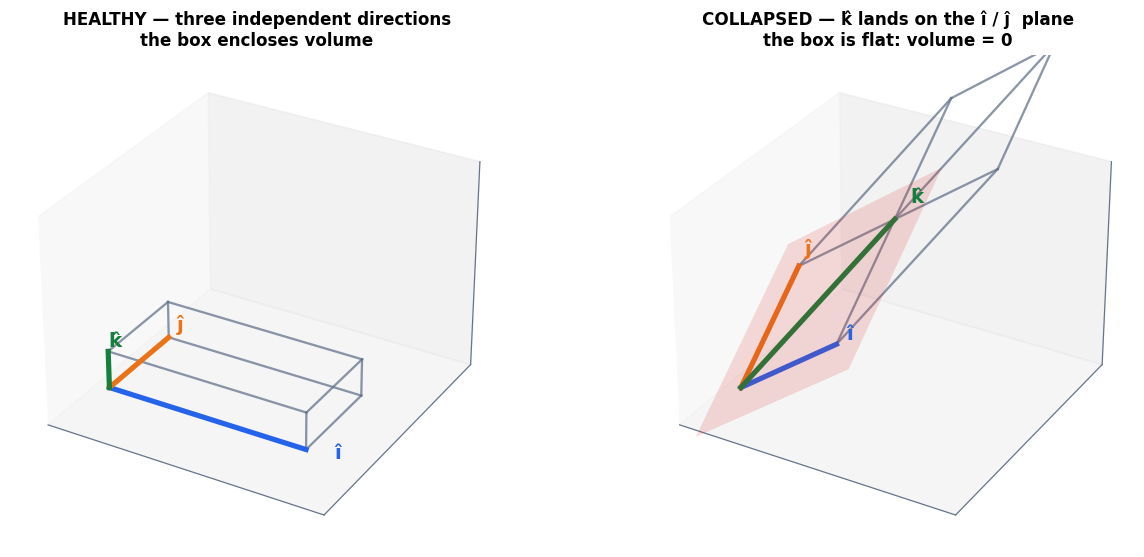

In [17]:
# ============================================================
#  Figure: three arrows that cannot cage any volume
# ============================================================
fig = plt.figure(figsize=(11.8, 5.2))

ax1 = fig.add_subplot(121, projection="3d")
draw_cube(ax1, A3, "HEALTHY — three independent directions\nthe box encloses volume", limit=2.4)

ax2 = fig.add_subplot(122, projection="3d")
pts = CUBE @ B3.T
for i, j in EDGES:
    ax2.plot(*zip(pts[i], pts[j]), color=C_GREY, lw=1.5, alpha=0.75)
for col, colr, name in [(0, C_DATA, "î"), (1, C_PRED, "ĵ"), (2, C_TRUE, "k̂")]:
    vec = B3[:, col]
    ax2.plot(*zip([0, 0, 0], vec), color=colr, lw=3.4)
    ax2.text(*(vec * 1.10), name, color=colr, fontsize=13, fontweight="bold")
# the plane the three arrows are trapped in
uu, vv = np.meshgrid(np.linspace(-0.3, 1.3, 6), np.linspace(-0.3, 1.3, 6))
plane = (uu[..., None] * B3[:, 0] + vv[..., None] * B3[:, 1])
ax2.plot_surface(plane[..., 0], plane[..., 1], plane[..., 2],
                 color=C_ERR, alpha=0.16, edgecolor="none")
ax2.set_xlim(-0.4, 2.4); ax2.set_ylim(-0.4, 2.4); ax2.set_zlim(-0.4, 2.4)
ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([]); ax2.grid(False)
ax2.set_title("COLLAPSED — k̂ lands on the î / ĵ  plane\nthe box is flat: volume = 0", fontsize=11)

plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — a healthy transformation.** The three landed arrows point in three genuinely independent directions, so the transformed cube is still a proper box with real volume. Any output in 3-D can be reached, and the transformation can be undone.

**Right — the collapse.** The red shaded surface is the plane spanned by where $\hat{\imath}$ and $\hat{\jmath}$ landed. Now look at the green $\hat{k}$ arrow: **it lies flat in that same plane**, because its column is exactly the sum of the other two. There is no third independent direction, so the transformed "cube" has been squashed perfectly flat.

**What to look for:** the flattened figure has no thickness. Its volume is exactly zero — not small, *zero*. Three arrows that all lie in one plane cannot cage any volume, no matter how long they are.

**Why this is fatal rather than merely inconvenient.** The code above found a whole *line* of inputs that $B$ sends to the origin, and showed two clearly different 3-D inputs landing on the identical output. Given only the output, you cannot say which input produced it — not because we lack a clever technique, but because the question genuinely has many answers. Undoing this would require inventing back the dimension that was deleted.

**The common misread:** the matrix is $3\times3$, so it *looks* like it fills 3-D. Shape is only a promise about the *maximum* number of dimensions the output could occupy. **Rank** is the actual count — here 2, not 3.


</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Shape is a promise. Rank is the reality.

Whenever you reason about dimensions from a matrix's shape alone, stop and ask: **how many of these columns actually point in independent directions?**

`np.linalg.matrix_rank(M)` answers it. For our $B$, the shape said 3 and the rank said 2 — and the rank was right.

</div>

## 3.4 Part 3 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- 3-D is the same idea with one more arrow: three basis vectors, three columns, everything else rides the grid.
- **An $m \times n$ matrix maps $\mathbb{R}^n \to \mathbb{R}^m$.** Wide lowers dimension, tall raises it, square preserves it — readable from the shape alone.
- Every neural-network layer is exactly this, and its shape is a **decision about how many dimensions to keep**.
- **A square matrix can still collapse** if its columns are not independent. Dimensionality change is not exotic; it is the default behaviour of every matrix.
- Collapse means **distinct inputs collide on one output**, which is precisely why no inverse can exist.
- **Shape is a promise; rank is the reality.**

### ➡️ Next Up

Every example in this Part came back to one quantity: how much the transformation squeezed space — 1 for a harmless stretch, 0 for a fatal collapse. That quantity has a name and an exact formula.

</div>


# Part 4 · The Determinant ⭐⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### One number, computed before you do anything else, that tells you whether space survives

You were probably taught $ad - bc$ as an incantation to memorise. It is correct, and it hides the idea completely.

**The determinant measures how much a transformation scales area (in 2-D) or volume (in 3-D) — and its sign says whether space was flipped.** Everything else, including $ad - bc$ itself, follows from that picture.


</div>

## 4.1 The Puzzle: What Happens to a Little Square

Draw the unit square — corners at $(0,0), (1,0), (1,1), (0,1)$. Its area is 1.

Now apply a transformation. The square is carried off to a **parallelogram** (straight lines stay straight, parallel lines stay parallel). What is the area of that new parallelogram?

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 That number *is* the determinant

If the parallelogram has area 6, then $\det(A) = 6$ — and the transformation multiplies **every** area in the plane by six. A triangle of area 0.5 becomes 3; a blob of area 10 becomes 60.

The scaling is uniform everywhere, which is a direct consequence of grid lines staying straight and evenly spaced.

</div>

## 4.2 Napkin Arithmetic on Real Matrices

**A stretch.** $A = \begin{bmatrix}3&0\\0&2\end{bmatrix}$: $\hat{\imath}$ lands at $(3,0)$, $\hat{\jmath}$ at $(0,2)$. The square is stretched to a $3 \times 2$ rectangle — area $6$. And the formula: $ad - bc = (3)(2) - (0)(0) = 6$. ✅

**A shear.** $B = \begin{bmatrix}1&1\\0&1\end{bmatrix}$: $\hat{\imath}$ stays at $(1,0)$, $\hat{\jmath}$ slides to $(1,1)$. The square tips into a leaning parallelogram — but the **base is still 1 and the height is still 1**, so the area is still 1. Formula: $(1)(1) - (1)(0) = 1$. ✅ *A pure shear slides space sideways without compressing it.*

**A swap.** $C = \begin{bmatrix}0&1\\1&0\end{bmatrix}$ exchanges the axes. A swapped unit square is still a unit square, so the area is 1 — but its **orientation flipped**, like turning a page over. Formula: $(0)(0) - (1)(1) = -1$. The magnitude 1 says the area is preserved; the minus sign says space was mirrored.

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 So $ad - bc$ is not an arbitrary incantation

$ad$ is the area of the axis-aligned rectangle the diagonal entries would make. $bc$ subtracts the area that the off-diagonal "lean" steals back. **Two costumes, one fact.**

</div>


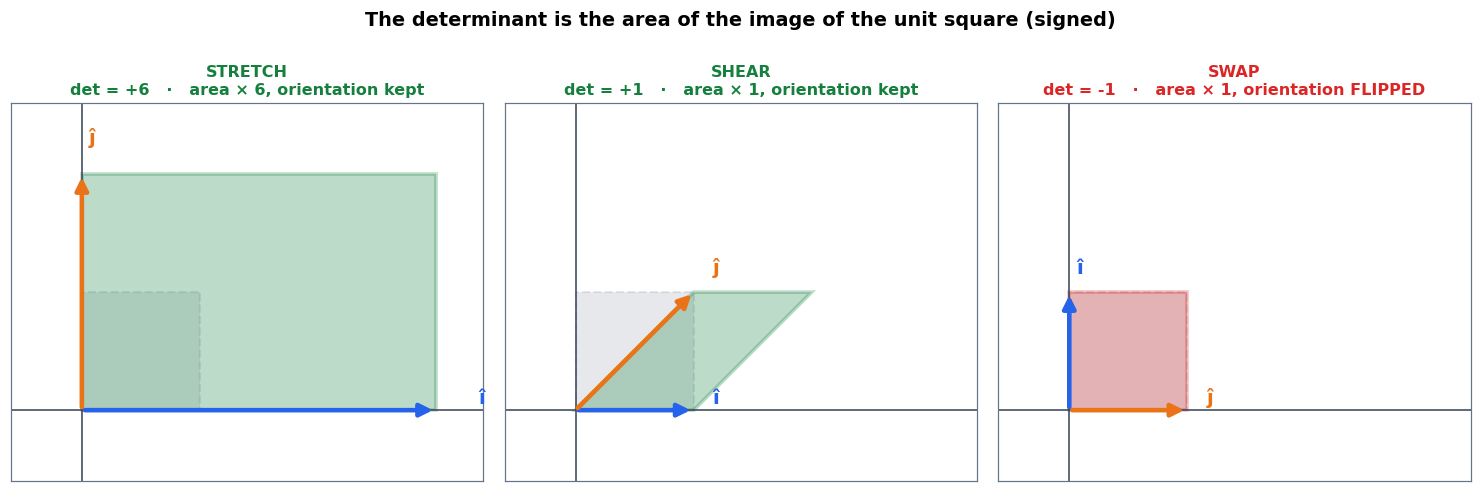

matrix         ad − bc   np.linalg.det
----------------------------------------
STRETCH            6.0          6.0000
SHEAR              1.0          1.0000
SWAP              -1.0         -1.0000


In [18]:
# ============================================================
#  Figure: three transformations, three area factors
# ============================================================
det_cases = [
    (np.array([[3., 0.], [0., 2.]]), "STRETCH",  "area × 6, orientation kept"),
    (np.array([[1., 1.], [0., 1.]]), "SHEAR",    "area × 1, orientation kept"),
    (np.array([[0., 1.], [1., 0.]]), "SWAP",     "area × 1, orientation FLIPPED"),
]

fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.6))
unit_square = np.array([[0, 0], [1, 0], [1, 1], [0, 1]], float)

for ax, (M, name, sub) in zip(axes, det_cases):
    d = np.linalg.det(M)
    # the original square, faintly
    ax.add_patch(Polygon(unit_square, closed=True, fc=C_GREY, ec=C_GREY,
                         alpha=0.16, lw=1.4, ls="--"))
    # the image
    img = unit_square @ M.T
    face = C_TRUE if d > 0 else C_ERR
    ax.add_patch(Polygon(img, closed=True, fc=face, ec=face, alpha=0.28, lw=2.4))
    for col, colr, nm in [(0, C_DATA, "î"), (1, C_PRED, "ĵ")]:
        vec = M[:, col]
        ax.annotate("", xy=vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=colr, lw=3, mutation_scale=17))
        ax.text(vec[0] * 1.1 + 0.06, vec[1] * 1.1 + 0.06, nm, color=colr,
                fontsize=13, fontweight="bold")
    ax.axhline(0, color="#334155", lw=1); ax.axvline(0, color="#334155", lw=1)
    ax.set_xlim(-0.6, 3.4); ax.set_ylim(-0.6, 2.6); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{name}\ndet = {d:+.0f}   ·   {sub}", fontsize=10.5,
                 color=C_TRUE if d > 0 else C_ERR)

fig.suptitle("The determinant is the area of the image of the unit square (signed)",
             fontsize=12.6, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print(f"{'matrix':<10}{'ad − bc':>12}{'np.linalg.det':>16}")
print("-" * 40)
for M, name, _ in det_cases:
    by_hand = M[0, 0] * M[1, 1] - M[0, 1] * M[1, 0]
    print(f"{name:<10}{by_hand:>12.1f}{np.linalg.det(M):>16.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**In every panel the faint dashed grey square is the original unit square (area 1), and the solid shape is where it landed.** The blue and orange arrows are, as always, the columns of the matrix.

**Stretch** — the square becomes a $3\times2$ rectangle. Six unit squares would fit inside it, and $\det = 6$. The transformation multiplies *every* area in the plane by six.

**Shear** — the square leans over into a parallelogram. It *looks* like it should have lost something, but the base is still 1 and the perpendicular height is still 1, so the area is unchanged: $\det = 1$. This is the panel that convinces people the determinant really is about area rather than about how "distorted" a shape looks.

**Swap** — the area is again unchanged, but the shape is shaded **red**, and the determinant is $-1$. Follow the arrows: in the first two panels going from blue to orange is an anticlockwise turn; here it is clockwise. Space has been mirrored, as if the page were turned over.

**What to look for:** the number below each panel is `ad − bc` computed by hand and by NumPy, and they agree exactly. The formula is not a separate fact to memorise — it is this picture, written in symbols.

**The common misread:** a determinant of $-1$ is not "smaller" than one of $2$. The comparison that matters is against **1 in absolute value**: $|\det| > 1$ expands area, $|\det| < 1$ shrinks it, $|\det| = 1$ does neither. The sign is a separate piece of information about orientation. A matrix stuffed with huge numbers can still have a tiny determinant, if its columns nearly line up and enclose almost no area.


</div>

## 4.3 The Number That Actually Matters: Zero

Everything above is scenery for one value. What happens when the determinant is **0**?

A zero area factor means the unit square is squashed to something with **no area at all**. A parallelogram with zero area is not a parallelogram — it is a line segment, or a point. The transformation has taken the full 2-D plane and flattened it onto a lower-dimensional shadow.

$$ C = \begin{bmatrix} 2 & 1 \\ 4 & 2 \end{bmatrix}, \qquad \det = 2 \cdot 2 - 1 \cdot 4 = 0 $$

$\hat{\imath}$ lands at $(2,4)$ and $\hat{\jmath}$ at $(1,2)$ — and the second is exactly **half** the first. Both basis vectors, and therefore every vector, land on the same line through the origin.


det(C) = 0.0000000000
column 2 = [1. 2.]   =   0.5 × column 1 = [1. 2.]
rank = 1  (not 2 — the plane became a line)

Two very different inputs, one identical output:
   C @ [1.0, 0.0]  =  [2. 4.]
   C @ [0.0, 2.0]  =  [2. 4.]

Given the output [2, 4], which input produced it? The question has
infinitely many answers. The information is gone — not hidden, GONE.


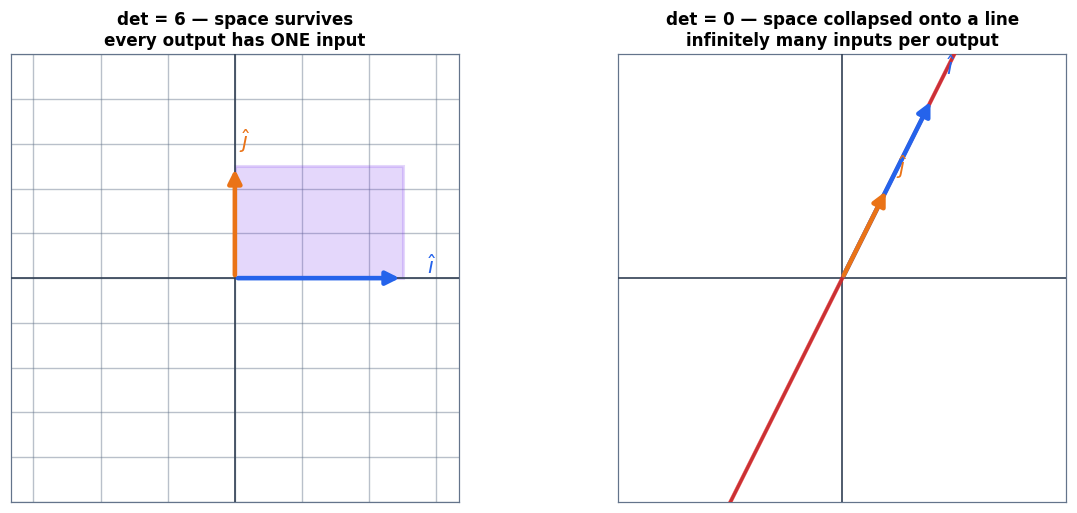

In [19]:
# ============================================================
#  det = 0: the plane flattened onto a line
# ============================================================
C = np.array([[2.0, 1.0],
              [4.0, 2.0]])

print(f"det(C) = {np.linalg.det(C):.10f}")
print(f"column 2 = {C[:, 1]}   =   0.5 × column 1 = {0.5 * C[:, 0]}")
print(f"rank = {np.linalg.matrix_rank(C)}  (not 2 — the plane became a line)")
print()
print("Two very different inputs, one identical output:")
for p in [np.array([1.0, 0.0]), np.array([0.0, 2.0])]:
    print(f"   C @ {p.tolist()}  =  {C @ p}")
print()
print("Given the output [2, 4], which input produced it? The question has")
print("infinitely many answers. The information is gone — not hidden, GONE.")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.6, 4.8))
draw_transform(axL, np.array([[3., 0.], [0., 2.]]), limit=4,
               title="det = 6 — space survives\nevery output has ONE input")
draw_transform(axR, C, limit=5,
               title="det = 0 — space collapsed onto a line\ninfinitely many inputs per output")
# emphasise the surviving line
tt = np.linspace(-5, 5, 10)
axR.plot(tt, 2 * tt, color=C_ERR, lw=2.6, alpha=0.85, zorder=4)
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — a healthy transformation.** The grid is stretched but still fills the plane: every intersection has moved somewhere distinct, and you could trace any output point back to exactly one input. The unit square still encloses area.

**Right — total collapse.** The entire grid has been crushed onto the single red line $y = 2x$. Every grid line, every square, every point of the plane now lies on that one line. The shaded unit square has no area left.

**What to look for:** on the right, the blue and orange arrows point along **the same line** — one is just half the length of the other. That is what "linearly dependent columns" looks like: the second column carries no direction the first did not already have.

**The consequence, which the printed output shows:** $(1,0)$ and $(0,2)$ — two obviously different starting points — both land on $(2,4)$. And they are not special; an entire line of inputs maps to that one point. Given the output, the input is unrecoverable.

**The common misread:** this is not a numerical accident that a better algorithm could work around. The collapse is a property of the transformation itself. No matrix $C^{-1}$ exists, because an inverse would have to send $(2,4)$ back to two different places at once.


</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Four statements that are one statement

$$ \det(A) = 0 \;\Longleftrightarrow\; \text{space collapses to a lower dimension} \;\Longleftrightarrow\; A \text{ is singular (no inverse)} \;\Longleftrightarrow\; \text{the columns are linearly dependent} $$

These are not four related facts to memorise. They are one geometric picture described four ways. A **nonzero** determinant, of any sign, means the map is invertible; zero means it is not.

</div>

## 4.4 Area Factors Multiply

If you apply $A$ and then $B$, areas scale by $\det(A)$ and then again by $\det(B)$. So:

$$ \det(BA) = \det(B)\cdot\det(A) $$

You do not need to memorise this — *a scaling of six followed by a scaling of two is a scaling of twelve.*

And it explains the zero case: **if any stage in a chain has determinant zero, the whole product is zero**, because once space is flattened onto a line no later stretch can un-flatten it.


In [20]:
# ============================================================
#  det(BA) = det(B)·det(A), and one zero poisons the chain
# ============================================================
A_s = np.array([[3., 0.], [0., 2.]])     # det 6
B_s = np.array([[1., 1.], [0., 1.]])     # det 1
print("A stretch (det 6) followed by a shear (det 1):")
print(f"   det(A) × det(B) = {np.linalg.det(A_s):.1f} × {np.linalg.det(B_s):.1f} "
      f"= {np.linalg.det(A_s) * np.linalg.det(B_s):.1f}")
print(f"   det(B @ A)      = {np.linalg.det(B_s @ A_s):.1f}")
print()
print("Now put ONE collapsing stage anywhere in the chain:")
pipeline = [("stretch", A_s), ("collapse", C), ("shear", B_s)]
prod = np.eye(2)
for name, M in pipeline:
    prod = M @ prod
    print(f"   after {name:<9} det = {np.linalg.det(prod):>8.4f}")
print()
print("Once it hits zero it stays zero. No later stage can restore a lost dimension.")


A stretch (det 6) followed by a shear (det 1):
   det(A) × det(B) = 6.0 × 1.0 = 6.0
   det(B @ A)      = 6.0

Now put ONE collapsing stage anywhere in the chain:
   after stretch   det =   6.0000
   after collapse  det =   0.0000
   after shear     det =   0.0000

Once it hits zero it stays zero. No later stage can restore a lost dimension.


## 4.5 Why a Practitioner Cares

This is not a geometry exercise. When you fit a **linear regression**, the closed-form solution

$$ \mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y} $$

contains an inverse — of a matrix built from your feature data. If two features are perfectly correlated (say `height_cm` and `height_inches`, or `height_m`), that matrix is **singular**, its determinant is zero, and the solver fails or returns nonsense.

🔗 *We will watch exactly this failure happen in Part 5.*

## 4.6 Part 4 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- The determinant is the **signed area (2-D) or volume (3-D) factor**: the area of the image of the unit square.
- $|\det| > 1$ expands, $|\det| < 1$ shrinks, $|\det| = 1$ preserves. The **sign** is separate — negative means orientation flipped (mirrored).
- $ad - bc$ is that picture in symbols: $ad$ is the rectangle, $bc$ subtracts the lean.
- **$\det = 0$ is the whole point**: space collapsed, information is destroyed, the matrix is singular, the columns are linearly dependent. One fact, four phrasings.
- Determinants **multiply** along a chain, so a single collapsing stage zeroes the whole pipeline.
- Big numbers in a matrix do *not* imply a big determinant — long columns pointing nearly the same way enclose almost no area.

### ➡️ Next Up

We know a zero determinant means "no inverse". Part 5 asks the sharper question: **what does undoing a transformation actually require, and what exactly does a singular matrix destroy?**

</div>


# Part 5 · Invertibility and Collapse ⭐⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### "The map collapses" is where understanding *begins*, not where it ends

We know a zero determinant means no inverse. Now the precise questions: **what does undoing a transformation literally require? Why does a nonzero determinant guarantee it is possible? And what exactly does a singular matrix destroy, such that no amount of cleverness recovers it?**


</div>

## 5.1 Undoing a Transformation Is a Concrete Thing

A matrix $A$ takes $\mathbf{x}$ to $A\mathbf{x}$. To **invert** it is to find the operation that reverses that — a matrix $A^{-1}$ satisfying

$$ A^{-1}A = I $$

where $I$ is the identity, the transformation that leaves every vector exactly where it was. Applying $I$ is the matrix equivalent of multiplying an ordinary number by 1.

So inverting is not abstract bookkeeping. If $A$ rotates the plane 30° anticlockwise, $A^{-1}$ rotates it 30° clockwise. If $A$ stretches $x$ by 3, $A^{-1}$ shrinks it by $\tfrac13$. **Every reversible transformation has a partner that puts space back.**

For $2\times2$ there is a closed form, and it makes the connection unmissable:

$$ A^{-1} = \frac{1}{ad - bc}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix} $$

Look at the denominator: it is $\det(A)$ itself. **Division by zero is undefined**, so this formula *literally ceases to exist* when the determinant is zero. That is not a quirk of the $2\times2$ case — it is the algebra saying exactly what the geometry said.


In [21]:
# ============================================================
#  The inverse, by formula and by NumPy — and what it undoes
# ============================================================
def inverse_2x2(M):
    """The closed form, written out so the determinant is visible."""
    (a, b), (c, d) = M
    det = a * d - b * c
    if np.isclose(det, 0):
        raise np.linalg.LinAlgError("det = 0 — this matrix has no inverse")
    return np.array([[d, -b], [-c, a]]) / det

A = np.array([[3.0, 1.0],
              [2.0, 4.0]])
A_inv_hand = inverse_2x2(A)

print(f"A =\n{A}\n")
print(f"det(A) = {np.linalg.det(A):.1f}\n")
print(f"A⁻¹ by the formula =\n{A_inv_hand.round(4)}\n")
print(f"A⁻¹ by NumPy       =\n{np.linalg.inv(A).round(4)}\n")
print(f"A⁻¹ @ A =\n{(A_inv_hand @ A).round(10)}   <- the identity")
print()

v = np.array([1.0, 2.0])
print("Round trip on a point:")
print(f"   start        {v}")
print(f"   after A      {A @ v}")
print(f"   after A⁻¹    {A_inv_hand @ (A @ v)}   <- back exactly where it started")


A =
[[3. 1.]
 [2. 4.]]

det(A) = 10.0

A⁻¹ by the formula =
[[ 0.4 -0.1]
 [-0.2  0.3]]

A⁻¹ by NumPy       =
[[ 0.4 -0.1]
 [-0.2  0.3]]

A⁻¹ @ A =
[[ 1.  0.]
 [-0.  1.]]   <- the identity

Round trip on a point:
   start        [1. 2.]
   after A      [ 5. 10.]
   after A⁻¹    [1. 2.]   <- back exactly where it started


## 5.2 Watch It Break, in Slow Motion

$$ A = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}, \qquad \det = 1\cdot4 - 2\cdot2 = 0 $$

The columns are $(1,2)$ and $(2,4)$ — the second is exactly twice the first, so every vector in the plane maps onto a single line of slope 2.

Now the fatal part. Push two clearly different inputs through:

$$ A\begin{bmatrix}2\\0\end{bmatrix} = \begin{bmatrix}2\\4\end{bmatrix}, \qquad A\begin{bmatrix}0\\1\end{bmatrix} = \begin{bmatrix}2\\4\end{bmatrix} $$

**Two different starting points. One identical output.** And they are not special — an entire line of inputs collapses onto that single point.


In [22]:
# ============================================================
#  The collision that makes an inverse impossible
# ============================================================
S = np.array([[1.0, 2.0],
              [2.0, 4.0]])
p1 = np.array([2.0, 0.0])
p2 = np.array([0.0, 1.0])

print(f"det(S) = {np.linalg.det(S):.1f}")
print(f"   S @ {p1.tolist()} = {S @ p1}")
print(f"   S @ {p2.tolist()} = {S @ p2}")
print(f"   different inputs? {not np.allclose(p1, p2)}   same output? {np.allclose(S @ p1, S @ p2)}")
print()
try:
    np.linalg.inv(S)
except np.linalg.LinAlgError as e:
    print(f"np.linalg.inv(S) raises: {type(e).__name__}: {e}")
print()
print("An inverse must recover the input UNIQUELY from the output.")
print("A transformation can be inverted only if it is ONE-TO-ONE.")
print("Collapsing a dimension guarantees the opposite: inputs collide.")


det(S) = 0.0
   S @ [2.0, 0.0] = [2. 4.]
   S @ [0.0, 1.0] = [2. 4.]
   different inputs? True   same output? True

np.linalg.inv(S) raises: LinAlgError: Singular matrix

An inverse must recover the input UNIQUELY from the output.
A transformation can be inverted only if it is ONE-TO-ONE.
Collapsing a dimension guarantees the opposite: inputs collide.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Linear dependence hides as a *ratio*, not as a repeat

It is tempting to think a matrix is only singular if it has a row of zeros or two identical rows. Consider

$$ B = \begin{bmatrix} 3 & 6 \\ 4 & 8 \end{bmatrix} $$

Four different entries, no zeros, no repeated rows. And $\det(B) = 3\cdot8 - 6\cdot4 = 24 - 24 = 0$: the second column is exactly $2\times$ the first.

**This is exactly how a bad feature enters a design matrix.** `height_cm` and `height_m` look like two different columns with different magnitudes — but one is $100\times$ the other, that hidden ratio drives the determinant to zero, and the system cannot be solved.

</div>

## 5.3 The Clean Chain of Equivalences

For a square matrix $A$, every one of these says the **same thing**:

$$ \det(A) \neq 0 \iff A \text{ is invertible} \iff \text{columns are linearly independent} \iff \text{no collapse} \iff A\mathbf{x} = \mathbf{0} \text{ only when } \mathbf{x} = \mathbf{0} $$

And the dark mirror, every clause negated at once:

$$ \det(A) = 0 \iff A \text{ is singular} \iff \text{columns are dependent} \iff \text{space collapses} \iff \text{some } \mathbf{x} \neq \mathbf{0} \text{ has } A\mathbf{x} = \mathbf{0} $$

Every arrow is bidirectional. Learn one, and you get four free.


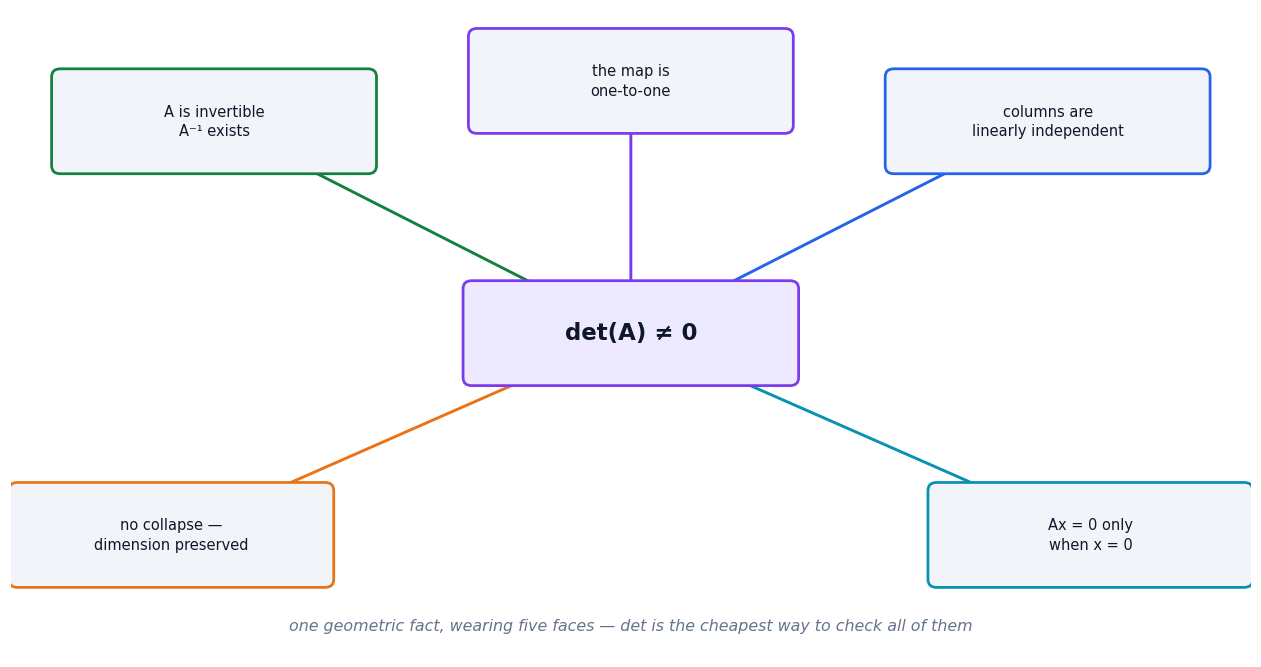

In [23]:
# ============================================================
#  Figure: five faces of one fact
# ============================================================
fig, ax = plt.subplots(figsize=(11.6, 6.2))
stage(ax, (0, 11.6), (0, 6.4))

centre = box(ax, 5.8, 3.2, 3.1, 1.0, "det(A) ≠ 0", fc="#EDE9FE", ec=C_MODEL,
             fs=15, bold=True)
spokes = [
    (1.9, 5.3, "A is invertible\nA⁻¹ exists", C_TRUE),
    (9.7, 5.3, "columns are\nlinearly independent", C_DATA),
    (1.5, 1.2, "no collapse —\ndimension preserved", C_PRED),
    (10.1, 1.2, "Ax = 0 only\nwhen x = 0", "#0891B2"),
    (5.8, 5.7, "the map is\none-to-one", C_MODEL),
]
for x, y, text, col in spokes:
    box(ax, x, y, 3.0, 1.0, text, fc=C_SOFT, ec=col, fs=9.6)
    arrow(ax, centre, (x, y), color=col, lw=1.9, style="<|-|>", ms=13)

ax.text(5.8, 0.25, "one geometric fact, wearing five faces — det is the cheapest way to check all of them",
        ha="center", fontsize=10.4, color=C_GREY, style="italic")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**The purple hub is a single number you can compute in one line; the five spokes are five very different-sounding claims about a matrix.** The arrows are **double-headed** on purpose: each spoke implies the hub and the hub implies each spoke.

**Read any two spokes against each other and you get a free theorem.** "The columns are linearly independent" and "the only solution to $A\mathbf{x} = \mathbf{0}$ is $\mathbf{x} = \mathbf{0}$" sound like statements about entirely different things — one about geometry, one about solving equations — yet they are the same statement, because dependent columns are *precisely* a recipe for a nonzero combination that cancels to nothing.

**What to look for:** every spoke is a *test you could run*, and they all cost different amounts. Checking one-to-one-ness directly would mean examining infinitely many pairs of inputs. Checking the determinant is one arithmetic expression. **That is what the determinant buys you: a cheap certificate for an expensive property.**

**The common misread:** on real data you will almost never see an exactly zero determinant — floating-point noise nudges it to something tiny but nonzero. The practical danger is a matrix that is **nearly** singular: an inverse exists in theory but is wildly unstable, and a whisper of noise in the input produces a shout in the output. This is why production pipelines use `numpy.linalg.lstsq` or ridge regression's $+\lambda I$ instead of computing an explicit inverse and testing `det == 0`.


</div>

In [24]:
# ============================================================
#  The failure that actually bites: a redundant feature
# ============================================================
gen = np.random.default_rng(SEED)
n = 200
height_cm = gen.normal(170, 8, n)
weight_kg = gen.normal(70, 12, n)
height_m  = height_cm / 100.0          # <- the SAME feature, different units

y_target = 0.4 * height_cm + 0.9 * weight_kg + gen.normal(0, 2, n)

def try_normal_equations(X, label):
    XtX = X.T @ X
    det = np.linalg.det(XtX)
    cond = np.linalg.cond(XtX)
    print(f"  {label}")
    print(f"     det(XᵀX)  = {det:>12.4e}")
    print(f"     cond(XᵀX) = {cond:>12.4e}", end="")
    try:
        w = np.linalg.inv(XtX) @ X.T @ y_target
        resid = np.linalg.norm(X @ w - y_target)
        print(f"   -> solved, residual {resid:.3f}, ‖w‖ = {np.linalg.norm(w):.3e}")
    except np.linalg.LinAlgError as e:
        print(f"   -> FAILED: {e}")
    print()

print("Fitting w = (XᵀX)⁻¹Xᵀy with and without a redundant feature")
print("=" * 66)
try_normal_equations(np.c_[height_cm, weight_kg], "healthy: [height_cm, weight_kg]")
try_normal_equations(np.c_[height_cm, weight_kg, height_m],
                     "redundant: [height_cm, weight_kg, height_m]  <- height twice")

print("The redundant design matrix is singular in exact arithmetic. In floating")
print("point the determinant is not quite 0, so the inverse 'succeeds' — and")
print("returns enormous, meaningless weights. THAT is why we use lstsq or ridge.")
w_ls, *_ = np.linalg.lstsq(np.c_[height_cm, weight_kg, height_m], y_target, rcond=None)
print(f"\n   np.linalg.lstsq gives a stable answer instead: ‖w‖ = {np.linalg.norm(w_ls):.3f}")


Fitting w = (XᵀX)⁻¹Xᵀy with and without a redundant feature
  healthy: [height_cm, weight_kg]
     det(XᵀX)  =   1.6298e+11
     cond(XᵀX) =   2.7332e+02   -> solved, residual 25.661, ‖w‖ = 9.690e-01

  redundant: [height_cm, weight_kg, height_m]  <- height twice
     det(XᵀX)  =  -1.8529e-02
     cond(XᵀX) =   3.1325e+20   -> solved, residual 1394.907, ‖w‖ = 1.406e+02

The redundant design matrix is singular in exact arithmetic. In floating
point the determinant is not quite 0, so the inverse 'succeeds' — and
returns enormous, meaningless weights. THAT is why we use lstsq or ridge.

   np.linalg.lstsq gives a stable answer instead: ‖w‖ = 0.969


# Part 6 · Eigenvectors — the Axes a Matrix Is Built Around ⭐⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### When a matrix stretches, rotates and shears the whole plane, is there anything it leaves pointing the same way?

Most vectors get knocked off their line. But for almost every matrix there are a few special directions that the transformation does **not turn** — it only stretches or squashes them along the line they were already on.

Those directions are the **eigenvectors**. The amount each is stretched is its **eigenvalue**. Find them and you have found the skeleton the transformation is built around.


</div>

## 6.1 The Equation, and Why It Says Exactly That

$$ \boxed{\; A\mathbf{v} = \lambda \mathbf{v} \;} $$

Read it aloud: *applying the transformation $A$ to the vector $\mathbf{v}$ gives you back the same vector $\mathbf{v}$, merely scaled by a number $\lambda$.* The direction is untouched; only the length changes.

**What the number means, geometrically:**

| $\lambda$ | What happens to that direction |
|---|---|
| $2$ | stretched to twice its length, same way |
| $1$ | left completely fixed — the transformation does not move it at all |
| $0.5$ | squashed to half length |
| $-1$ | **flipped** to point the opposite way, same length (a reflection along that axis) |
| $0$ | **collapsed to the origin** — the whole line crushed to a point |

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔗 That last row closes the loop with Parts 4 and 5

**The determinant equals the product of the eigenvalues.** So if even one eigenvalue is 0, the product is 0, the determinant is 0, and the matrix is singular — it has flattened at least one direction into a lower dimension.

The collapse we drew geometrically, and certified with $\det$, is *the same event* as one eigenvalue hitting zero.

</div>


## 6.2 ✍️ A Napkin Example, Ground Through by Hand

Abstractions dissolve the moment you do one yourself. Take the shear-and-stretch

$$ A = \begin{bmatrix} 2 & 1 \\ 0 & 3 \end{bmatrix} $$

**Step 1 — turn the definition into something solvable.** We want $A\mathbf{v} = \lambda\mathbf{v}$, which rearranges to

$$ (A - \lambda I)\mathbf{v} = \mathbf{0} $$

This has a *nonzero* solution $\mathbf{v}$ only when the matrix $(A - \lambda I)$ **collapses space** — and from Part 4 we know exactly when that happens:

$$ \det(A - \lambda I) = 0 \qquad \text{(the characteristic equation)} $$

**Step 2 — write it out and solve for $\lambda$.**

$$ A - \lambda I = \begin{bmatrix} 2-\lambda & 1 \\ 0 & 3-\lambda \end{bmatrix} \qquad\Rightarrow\qquad \det = (2-\lambda)(3-\lambda) - (1)(0) = (2-\lambda)(3-\lambda) $$

Setting that to zero: $\;\lambda_1 = 2, \; \lambda_2 = 3$.

*Sanity check:* $2 \times 3 = 6$, and $\det(A) = 2\cdot3 - 1\cdot0 = 6$. **The product-of-eigenvalues rule, confirmed by hand.**

**Step 3 — back-substitute to find each direction.**

For $\lambda_1 = 2$: $\;(A - 2I) = \begin{bmatrix} 0 & 1 \\ 0 & 1\end{bmatrix}$. Multiplying by $\mathbf{v} = (x,y)$, both rows demand $y = 0$. So the eigenvector is $(1, 0)$ — **the horizontal axis**, which matches the intuition that a shear leaves the $x$-axis pointing along itself.

For $\lambda_2 = 3$: $\;(A - 3I) = \begin{bmatrix} -1 & 1 \\ 0 & 0\end{bmatrix}$, giving $-x + y = 0$, so $y = x$. The eigenvector is $(1, 1)$ — a diagonal direction stretched by 3.


In [25]:
# ============================================================
#  The hand calculation, checked three ways
# ============================================================
import sympy as sp

Ae = np.array([[2.0, 1.0],
               [0.0, 3.0]])

# --- 1. symbolically, exactly as we did on paper ---
lam = sp.symbols("lambda")
As = sp.Matrix([[2, 1], [0, 3]])
char_poly = sp.factor(sp.det(As - lam * sp.eye(2)))
print("characteristic equation  det(A − λI) = 0")
print(f"   {char_poly} = 0")
print(f"   roots: {sorted(sp.solve(sp.Eq(char_poly, 0), lam))}")
print(f"   sympy eigenvectors: {As.eigenvects()}")
print()

# --- 2. numerically with NumPy ---
vals, vecs = np.linalg.eig(Ae)
print(f"np.linalg.eig eigenvalues : {vals}")
print(f"   eigenvector for λ={vals[0]:.0f}: {vecs[:, 0].round(4)}")
print(f"   eigenvector for λ={vals[1]:.0f}: {vecs[:, 1].round(4)}   (that is (1,1)/√2)")
print()

# --- 3. the defining property, verified directly ---
print("Does A @ v really equal λ · v ?")
for k in range(2):
    v_k, l_k = vecs[:, k], vals[k]
    print(f"   A @ v = {(Ae @ v_k).round(4)}    λ·v = {(l_k * v_k).round(4)}"
          f"    match: {np.allclose(Ae @ v_k, l_k * v_k)}")
print()
print(f"product of eigenvalues = {vals.prod():.4f}   ·   det(A) = {np.linalg.det(Ae):.4f}")


characteristic equation  det(A − λI) = 0
   (lambda - 3)*(lambda - 2) = 0
   roots: [2, 3]
   sympy eigenvectors: [(2, 1, [Matrix([
[1],
[0]])]), (3, 1, [Matrix([
[1],
[1]])])]

np.linalg.eig eigenvalues : [2. 3.]
   eigenvector for λ=2: [1. 0.]
   eigenvector for λ=3: [0.7071 0.7071]   (that is (1,1)/√2)

Does A @ v really equal λ · v ?
   A @ v = [2. 0.]    λ·v = [2. 0.]    match: True
   A @ v = [2.1213 2.1213]    λ·v = [2.1213 2.1213]    match: True

product of eigenvalues = 6.0000   ·   det(A) = 6.0000


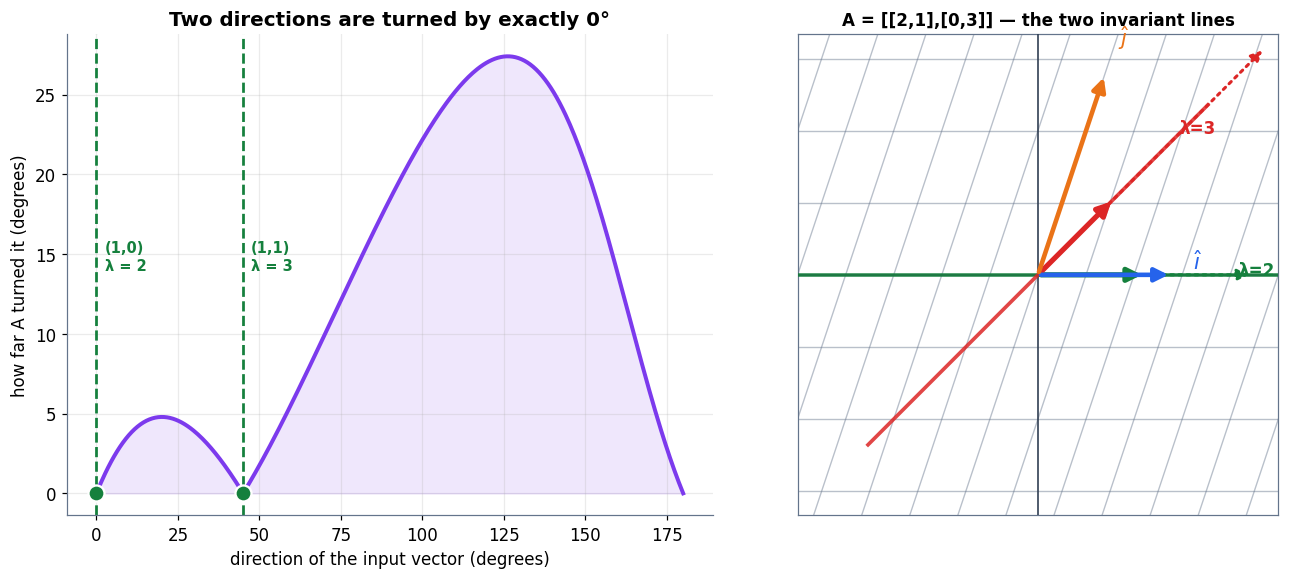

In [26]:
# ============================================================
#  Figure: most arrows get turned; eigenvectors do not
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 5.4))

# ── left: sweep a probe around and measure how far it was turned ──
angles = np.linspace(0, np.pi, 400)          # half turn is enough (lines, not arrows)
turned = []
for t in angles:
    v_in = np.array([np.cos(t), np.sin(t)])
    v_out = Ae @ v_in
    v_out = v_out / np.linalg.norm(v_out)
    turned.append(np.degrees(np.arccos(np.clip(abs(v_in @ v_out), -1, 1))))
turned = np.array(turned)

ax1.plot(np.degrees(angles), turned, color=C_MODEL, lw=2.6)
ax1.fill_between(np.degrees(angles), 0, turned, color=C_MODEL, alpha=0.12)
for ang, lab, lval in [(0.0, "(1,0)", 2), (45.0, "(1,1)", 3)]:
    ax1.axvline(ang, color=C_TRUE, ls="--", lw=1.8)
    ax1.text(ang + 2.5, 14, f"{lab}\nλ = {lval}", color=C_TRUE,
             fontsize=9.6, fontweight="bold")
ax1.scatter([0.0, 45.0], [0.0, 0.0], s=110, color=C_TRUE, zorder=6,
            edgecolor="white", lw=1.5)
tidy(ax1, "direction of the input vector (degrees)",
     "how far A turned it (degrees)",
     "Two directions are turned by exactly 0°")

# ── right: the eigenvectors drawn on the transformed grid ──
draw_transform(ax2, Ae, limit=3.6, title="A = [[2,1],[0,3]] — the two invariant lines",
               show_unit_square=False)
for vec, lval, col in [(np.array([1.0, 0.0]), 2, C_TRUE),
                       (np.array([1.0, 1.0]) / np.sqrt(2), 3, C_ERR)]:
    tt = np.linspace(-3.6, 3.6, 10)
    ax2.plot(tt * vec[0], tt * vec[1], color=col, lw=2.4, alpha=0.85, zorder=4)
    ax2.annotate("", xy=vec * 1.6, xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", color=col, lw=3.4, mutation_scale=18))
    ax2.annotate("", xy=Ae @ (vec * 1.6), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", color=col, lw=2.0,
                                 mutation_scale=15, linestyle=":"))
    ax2.text(*(vec * 3.0), f"λ={lval}", color=col, fontsize=11, fontweight="bold", zorder=7)

plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — a search for the survivors.** We take a unit vector, point it at every angle from 0° to 180°, push it through $A$, and measure **how far the transformation turned it**. The purple curve is that turning angle.

Almost every direction gets rotated by something. But the curve touches **zero** in exactly two places, marked with green dots: at 0° (the direction $(1,0)$) and at 45° (the direction $(1,1)$). Those are the two directions $A$ leaves pointing exactly where they were — the eigenvectors, *found by search* rather than by algebra, and landing precisely where the hand calculation said they would.

**Right — the same two directions drawn on the transformed grid.** Each coloured line is an eigenvector's span. The thick solid arrow is the vector before the transformation; the thin dotted arrow is where $A$ sent it. Notice they lie **along the same line** — the dotted arrow is simply longer. That is the whole content of $A\mathbf{v} = \lambda\mathbf{v}$, drawn: green stretched by 2, red stretched by 3.

**What to look for:** every *other* grid line in that picture has been tilted. These two lines are the skeleton the transformation pivots around.

**The common misread:** an eigenvector is a **direction**, not a particular arrow. $(1,1)$, $(2,2)$ and $(-5,-5)$ are all the same eigenvector, which is why NumPy hands them back normalised to length 1 — you will see $(0.707, 0.707)$ rather than $(1,1)$, and it means the same thing.


</div>

## 6.3 ⚠️ The Pitfall: What if No Arrow Survives?

The picture of a stubborn direction is intuitive enough that people assume every matrix must have one. **Not true.**

Take a pure 90° rotation, $R = \begin{bmatrix}0&-1\\1&0\end{bmatrix}$. Spin the plane a quarter turn and ask which arrow landed back on its own line: **none of them do.** A quarter turn changes every direction.

The algebra agrees:

$$ \det(R - \lambda I) = (-\lambda)(-\lambda) - (-1)(1) = \lambda^2 + 1 = 0 $$

which has no real solution — we would need $\lambda^2 = -1$. The eigenvalues are the complex numbers $+i$ and $-i$.

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ And why symmetric matrices are the ones ML cares about

A real matrix can have **no real eigenvectors**. That is not an error; it usually means the transformation is *rotating* rather than stretching.

**Symmetric matrices** ($A = A^\top$) are a well-behaved family that is *guaranteed* real eigenvalues and *orthogonal* eigenvectors. Covariance matrices are symmetric — which is exactly why PCA never runs into imaginary numbers. Use `np.linalg.eigh` (not `eig`) for them: it is faster, more accurate, and guarantees those properties.

</div>


In [27]:
# ============================================================
#  A rotation has no real eigenvectors — and a symmetric matrix always does
# ============================================================
R = np.array([[0.0, -1.0], [1.0, 0.0]])       # 90° rotation
vals_R = np.linalg.eigvals(R)
print(f"rotation eigenvalues: {vals_R}   <- purely imaginary, no real direction survives")
print(f"   det(R − λI) = λ² + 1 = 0  requires λ² = −1")
print()

Sym = np.array([[4.0, 1.0], [1.0, 3.0]])      # symmetric
vals_S, vecs_S = np.linalg.eigh(Sym)          # eigh, not eig
print(f"symmetric matrix eigenvalues: {vals_S.round(4)}   <- real, guaranteed")
print(f"   eigenvectors are orthogonal? "
      f"{np.isclose(vecs_S[:, 0] @ vecs_S[:, 1], 0)}  "
      f"(their dot product = {vecs_S[:, 0] @ vecs_S[:, 1]:.2e})")
print()
print("Recall Part 2: a dot product of zero means perpendicular.")
print("Symmetric matrices hand you a perpendicular set of axes for free.")
print("Covariance matrices are symmetric — which is the whole basis of PCA.")


rotation eigenvalues: [0.+1.j 0.-1.j]   <- purely imaginary, no real direction survives
   det(R − λI) = λ² + 1 = 0  requires λ² = −1

symmetric matrix eigenvalues: [2.382 4.618]   <- real, guaranteed
   eigenvectors are orthogonal? True  (their dot product = 0.00e+00)

Recall Part 2: a dot product of zero means perpendicular.
Symmetric matrices hand you a perpendicular set of axes for free.
Covariance matrices are symmetric — which is the whole basis of PCA.


# Part 7 · Capstone — the MODEL Box, Assembled ⭐⭐⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Two payoffs that use everything in this notebook

**One:** a neural network layer, taken apart into the dot products it really is.
**Two:** PCA — built from scratch out of covariance and eigenvectors, then checked against scikit-learn.


</div>

## 7.1 A Layer Is a Wide Matrix of Dot Products

In Notebook 1 the model was $\hat{y} = w \cdot x + b$ — one dot product. A network layer is the same thing stacked: **one row of $W$ per output unit, each row doing its own dot product with the input.**

$$ \mathbf{z} = W\mathbf{x} + \mathbf{b}, \qquad W \in \mathbb{R}^{\text{out} \times \text{in}} $$

Every idea in this notebook is present in that one line: the matrix is a **transformation** (Part 1), each row is a **dot product** measuring alignment (Part 2), the shape is a deliberate **dimension change** (Part 3), and whether information survives depends on the **rank** (Parts 4–5).


In [28]:
# ============================================================
#  A layer, decomposed into the dot products it really is
# ============================================================
gen = np.random.default_rng(SEED)
n_in, n_out = 6, 3
W = gen.normal(0, 0.6, size=(n_out, n_in))
b_vec = gen.normal(0, 0.2, size=n_out)
x_in = gen.normal(0, 1.0, size=n_in)

z = W @ x_in + b_vec

print(f"W has shape {W.shape}  ->  it maps R^{n_in} → R^{n_out}")
print(f"rank of W = {np.linalg.matrix_rank(W)}  (full rank: no dimension wasted)")
print()
print("Each output is ONE dot product of a row of W with the input:")
print(f"{'unit':>6}{'row · x':>12}{'+ bias':>10}{'= z':>10}")
print("-" * 40)
for k in range(n_out):
    dotp = W[k] @ x_in
    print(f"{k:>6}{dotp:>12.4f}{b_vec[k]:>10.4f}{z[k]:>10.4f}")
print("-" * 40)
print(f"matrix form  W @ x + b = {z.round(4)}")
print(f"identical?   {np.allclose(z, np.array([W[k] @ x_in + b_vec[k] for k in range(n_out)]))}")
print()
print(f"A 6-dimensional input became a 3-dimensional one. {n_in - n_out} dimensions")
print("were discarded — deliberately. That is what the layer is FOR.")


W has shape (3, 6)  ->  it maps R^6 → R^3
rank of W = 3  (full rank: no dimension wasted)

Each output is ONE dot product of a row of W with the input:
  unit     row · x    + bias       = z
----------------------------------------
     0      1.1927   -0.3802    0.8125
     1     -1.7600   -0.2579   -2.0179
     2      1.5951   -0.3683    1.2268
----------------------------------------
matrix form  W @ x + b = [ 0.8125 -2.0179  1.2268]
identical?   True

A 6-dimensional input became a 3-dimensional one. 3 dimensions
were discarded — deliberately. That is what the layer is FOR.


## 7.2 PCA: the Eigenvectors of Your Data

Here is the payoff that makes Part 6 worth the effort.

Take a cloud of data points and compute its **covariance matrix** — a symmetric matrix summarising how the features vary and co-vary. Its **eigenvectors point along the principal axes of the cloud**, and each **eigenvalue measures how much variance the data spreads along that axis**.

- largest eigenvalue → the direction of greatest spread
- smallest eigenvalue → the direction the data barely uses

**That is Principal Component Analysis.** Rank the eigenvectors by eigenvalue, keep the top few, and you have compressed high-dimensional data down to the handful of axes that actually carry its structure.

Let us build it from scratch — four lines — and then check it against scikit-learn.


In [29]:
# ============================================================
#  PCA from scratch: centre, covariance, eigh, project
# ============================================================
# A deliberately tilted, elongated cloud so the axes are visible
gen = np.random.default_rng(SEED)
base = gen.normal(0, 1, size=(300, 2)) * np.array([2.6, 0.55])
theta = np.radians(32)
Rot = np.array([[np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]])
cloud = base @ Rot.T + np.array([4.0, 2.0])

# ── PCA, in four lines ──
centred = cloud - cloud.mean(axis=0)              # 1. centre it
cov = np.cov(centred, rowvar=False)               # 2. covariance matrix (symmetric!)
eigvals, eigvecs = np.linalg.eigh(cov)            # 3. eigh — real, orthogonal, guaranteed
order = np.argsort(eigvals)[::-1]                 # 4. rank by variance, largest first
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

print("covariance matrix (symmetric — check the off-diagonals):")
print(cov.round(4))
print(f"\nis it symmetric? {np.allclose(cov, cov.T)}")
print()
print(f"{'component':>11}{'eigenvalue':>14}{'variance share':>17}{'direction':>22}")
print("-" * 66)
total = eigvals.sum()
for k in range(2):
    print(f"{'PC' + str(k+1):>11}{eigvals[k]:>14.4f}{eigvals[k]/total:>16.1%}"
          f"{str(eigvecs[:, k].round(3).tolist()):>22}")
print("-" * 66)
print(f"the two axes are perpendicular: dot = {eigvecs[:,0] @ eigvecs[:,1]:.2e}")
print()

# ── check against scikit-learn ──
from sklearn.decomposition import PCA
sk = PCA(n_components=2).fit(cloud)
print("scikit-learn agrees:")
print(f"   our eigenvalues      {eigvals.round(4)}")
print(f"   sklearn variances    {sk.explained_variance_.round(4)}")
print(f"   our PC1 direction    {np.abs(eigvecs[:, 0]).round(4)}")
print(f"   sklearn PC1          {np.abs(sk.components_[0]).round(4)}")
print(f"   match (up to sign)?  {np.allclose(np.abs(eigvecs[:,0]), np.abs(sk.components_[0]), atol=1e-6)}")


covariance matrix (symmetric — check the off-diagonals):
[[4.111  2.4363]
 [2.4363 1.8002]]

is it symmetric? True

  component    eigenvalue   variance share             direction
------------------------------------------------------------------
        PC1        5.6520           95.6%      [-0.845, -0.535]
        PC2        0.2593            4.4%       [0.535, -0.845]
------------------------------------------------------------------
the two axes are perpendicular: dot = 0.00e+00

scikit-learn agrees:
   our eigenvalues      [5.652  0.2593]
   sklearn variances    [5.652  0.2593]
   our PC1 direction    [0.8451 0.5346]
   sklearn PC1          [0.8451 0.5346]
   match (up to sign)?  True


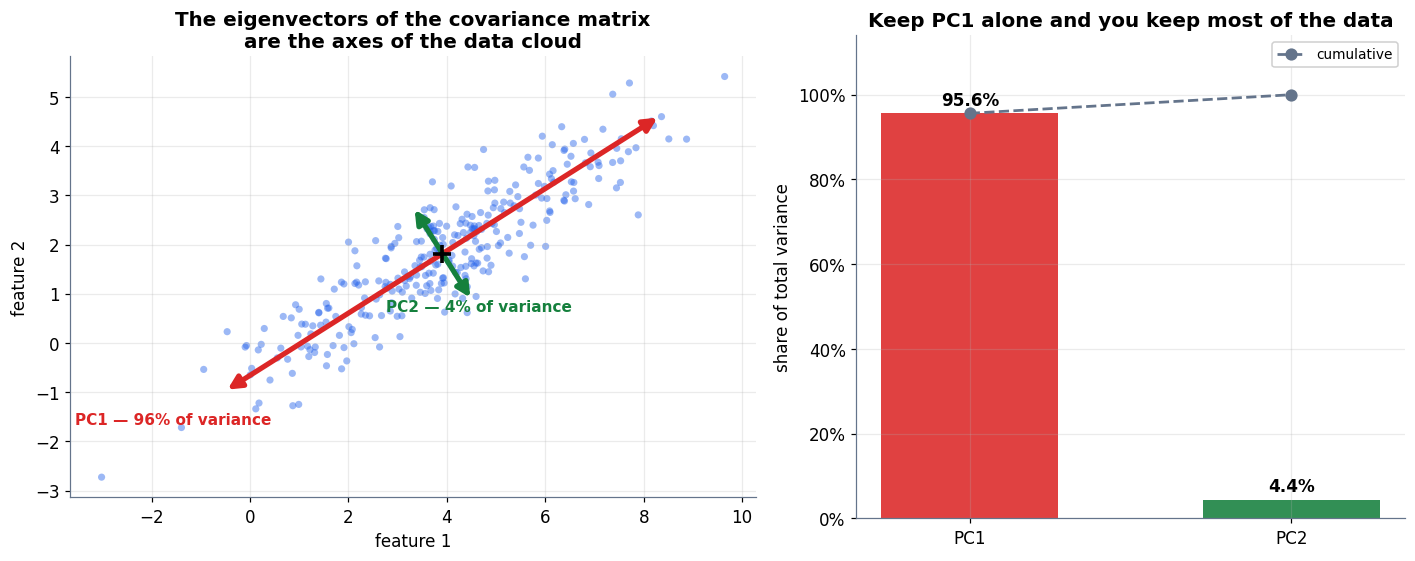

In [30]:
# ============================================================
#  Figure: the data cloud and the axes it is built around
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2),
                               gridspec_kw={"width_ratios": [1.25, 1]})

# ── left: the cloud with its principal axes ──
mu = cloud.mean(axis=0)
ax1.scatter(*cloud.T, s=22, color=C_DATA, alpha=0.45, edgecolor="none")
ax1.scatter(*mu, s=150, color="black", marker="+", lw=2.4, zorder=6)
for k, (col, lab) in enumerate([(C_ERR, "PC1"), (C_TRUE, "PC2")]):
    direction = eigvecs[:, k] * np.sqrt(eigvals[k]) * 2.2
    # draw each principal component as a double-headed AXIS through the mean,
    # because an eigenvector describes a LINE, not a one-way arrow
    ax1.annotate("", xy=mu + direction, xytext=mu - direction,
                 arrowprops=dict(arrowstyle="<|-|>", color=col, lw=3.4,
                                 mutation_scale=18))
    ax1.text(*(mu + direction * 1.24),
             lab + " — " + f"{eigvals[k]/total:.0%} of variance",
             color=col, fontsize=10, fontweight="bold", ha="center")
ax1.set_aspect("equal")
tidy(ax1, "feature 1", "feature 2",
     "The eigenvectors of the covariance matrix\nare the axes of the data cloud")

# ── right: variance explained ──
ax2.bar(["PC1", "PC2"], eigvals / total, color=[C_ERR, C_TRUE], alpha=0.88, width=0.55)
for k in range(2):
    ax2.text(k, eigvals[k] / total + 0.02, f"{eigvals[k]/total:.1%}",
             ha="center", fontsize=11, fontweight="bold")
ax2.plot([0, 1], np.cumsum(eigvals / total), "o--", color=C_GREY, lw=1.8,
         ms=7, label="cumulative")
ax2.set_ylim(0, 1.14)
ax2.yaxis.set_major_formatter(lambda v, p: f"{v:.0%}")
tidy(ax2, None, "share of total variance",
     "Keep PC1 alone and you keep most of the data", legend=True)

plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


**Left — a cloud of 300 points and the two arrows that describe it.** The black cross is the mean. The red arrow (**PC1**) points along the direction the data spreads *most*; the green arrow (**PC2**) points along the direction it spreads *least*. Each arrow's length is scaled by the square root of its eigenvalue, so the picture shows the actual shape of the spread.

**These arrows were not fitted, drawn by eye, or optimised.** They are the eigenvectors of the covariance matrix — the output of `np.linalg.eigh`, three lines of code. Part 6 said an eigenvector is a direction a transformation only *scales*; here the transformation is the data's own covariance, and the directions it scales are the axes the cloud is built along.

**Notice the two arrows are perpendicular.** That is not luck — it is the guarantee from §6.3 that a symmetric matrix has orthogonal eigenvectors, and a covariance matrix is always symmetric. This is the reason PCA always hands you a clean set of right-angled axes.

**Right — how much each axis is worth.** PC1 carries the overwhelming majority of the variance and PC2 almost none. **That is the compression opportunity**: project every point onto PC1 alone and you go from 2 numbers per point to 1, while keeping nearly all of the structure.

**What to look for:** the cloud is tilted, so *neither original feature axis* describes it well. PCA found the coordinate system the data actually lives in, rather than the arbitrary one it was recorded in.

**The common misread:** PCA keeps directions of maximum **variance**, not maximum **usefulness**. If the signal you care about happens to live in a low-variance direction, PCA will happily throw it away. Variance is a proxy for information, and sometimes a bad one.


</div>

---

# 🏆 Cheat Sheet

## The one idea

**A matrix is a function that moves space. Its columns are where the basis vectors land.** Everything else is a consequence.

## The objects

| Thing | Meaning | NumPy |
|---|---|---|
| $A\mathbf{x}$ | transform $\mathbf{x}$; a weighted sum of $A$'s columns | `A @ x` |
| $\mathbf{a}\cdot\mathbf{x}$ | collapse to a number = $\vert\mathbf{a}\vert\times$(projection) | `a @ x` |
| $\cos\theta$ | alignment alone, length divided out, in $[-1,1]$ | `a@x/(norm(a)*norm(x))` |
| shape $m\times n$ | maps $\mathbb{R}^n\to\mathbb{R}^m$ | `A.shape` |
| rank | how many dimensions the output *actually* uses | `matrix_rank(A)` |
| $\det(A)$ | signed area/volume factor | `det(A)` |
| $A^{-1}$ | the transformation that undoes $A$ | `inv(A)` |
| $\lambda, \mathbf{v}$ | stretch factor and the direction it stretches | `eig(A)` / `eigh(A)` |

## The equivalence chain (memorise one, get five)

$$ \det(A)\neq 0 \iff \text{invertible} \iff \text{columns independent} \iff \text{no collapse} \iff A\mathbf{x}=\mathbf{0}\text{ only for }\mathbf{x}=\mathbf{0} $$

## The dot product's three cases

| $\mathbf{a}\cdot\mathbf{x}$ | Angle | Meaning |
|---|---|---|
| $> 0$ | $< 90°$ | aligned |
| $= 0$ | $= 90°$ | **perpendicular** |
| $< 0$ | $> 90°$ | opposed |

## Eigenvalues at a glance

$\lambda>1$ stretch · $\lambda=1$ fixed · $0<\lambda<1$ shrink · $\lambda<0$ flip · $\lambda=0$ **collapse**
And: $\det(A) = \prod \lambda_i$.

## PCA in four lines

```python
centred = X - X.mean(axis=0)
cov     = np.cov(centred, rowvar=False)
vals, vecs = np.linalg.eigh(cov)       # eigh: symmetric ⇒ real + orthogonal
order   = np.argsort(vals)[::-1]       # rank by variance
```

---

# ⚠️ Common Pitfalls to Avoid

1. **Reading rows as landing spots.** $\hat{\imath}$ lands on the first **column**, read downward. For a symmetric matrix the mistake hides; for a rotation it gives you a completely wrong picture.
2. **Forgetting that order matters.** $AB \neq BA$. In $A(B\mathbf{x})$ the rightmost matrix acts **first** — right to left, like nested functions. Swapping two network layers is a different model.
3. **Trusting shape over rank.** A $3\times3$ matrix can still collapse to a plane. Shape is a promise; **rank is the reality**.
4. **Comparing raw dot products.** A big value may mean *long*, not *aligned*. Use cosine similarity when you mean alignment — this is why retrieval systems normalise embeddings.
5. **Reading $\det$ as "size".** $-1$ is not smaller than $2$. Compare $|\det|$ against **1**, and read the sign separately as orientation.
6. **Assuming big entries mean a big determinant.** Long columns pointing nearly the same way enclose almost no area.
7. **Testing `det == 0` on real data.** Floating-point noise makes it almost never exactly zero. The real danger is *nearly* singular — check the **condition number**, and prefer `lstsq` or ridge over an explicit `inv`.
8. **Duplicating a feature in different units.** `height_cm` and `height_m` are one feature twice; the hidden ratio makes $X^\top X$ singular and the solver returns nonsense.
9. **Expecting every matrix to have real eigenvectors.** A rotation has none. Use `eigh` for symmetric matrices and `eig` only when you must.
10. **Believing PCA keeps what matters.** It keeps what **varies**. If your signal lives in a low-variance direction, PCA discards it.

---

# 🧠 Self-Check

| # | Can you… | Part |
|---|---|---|
| 1 | Look at $\begin{bmatrix}0&-1\\1&0\end{bmatrix}$ and say what it does, without multiplying anything? | 1 |
| 2 | Explain why matrix-vector multiplication is a weighted sum of columns? | 1 |
| 3 | Explain how $\sum a_ib_i$ and $\vert a\vert\vert b\vert\cos\theta$ can possibly be the same number? | 2 |
| 4 | Give an example where the larger dot product is the worse match? | 2 |
| 5 | Say why a $3\times3$ matrix might still only reach a 2-D output? | 3 |
| 6 | Derive $ad-bc$ from the area of a parallelogram? | 4 |
| 7 | State the five-way equivalence chain and explain *why* collapse forbids an inverse? | 4–5 |
| 8 | Find the eigenvalues of $\begin{bmatrix}2&1\\0&3\end{bmatrix}$ by hand via $\det(A-\lambda I)=0$? | 6 |
| 9 | Explain what $\lambda=0$ means and how it links back to the determinant? | 6 |
| 10 | Explain PCA in one sentence using the word "eigenvector"? | 7 |

**Extensions:**

- **A.** Build the matrix that reflects the plane across the line $y = x$. Predict its determinant and eigenvalues *before* computing them, then check.
- **B.** Take the collapsing matrix $\begin{bmatrix}1&2\\2&4\end{bmatrix}$ and find its eigenvalues. Which one is zero, and what is the eigenvector for it? Relate that vector to the null space.
- **C.** Generate a cloud where PC1 and PC2 have nearly equal eigenvalues. What happens to the PCA axes across repeated random draws, and why is that unstable?
- **D.** Add a third feature to the PCA cloud that is an exact linear combination of the first two. What is the third eigenvalue, and what does that tell you about the rank?

---

# 📚 References

**The source for this notebook**
- *Foundations for AI &amp; ML* — Vizuara. This notebook covers the entire **Linear Algebra for ML** section: *Matrix-Vector Multiplication as a Transformation*, *The Dot Product as a Linear Transformation*, *Linear Transformations in 3D and Dimensionality Change*, *The Determinant: What It Measures*, *Determinants Deeper: Invertibility and Collapse*, and *Eigenvalues and Eigenvectors, Intuitively*.

**To see it move**
- 3Blue1Brown — *Essence of Linear Algebra*. The visual canon for everything in Parts 1, 4 and 6.

**To go deeper**
- Strang, *Introduction to Linear Algebra* — the standard text; chapters on determinants and eigenvalues.
- Deisenroth, Faisal &amp; Ong, *Mathematics for Machine Learning*, chapters 2–4.

**Elsewhere in this series**
- `foundations_1_the_learning_machine.ipynb` — the four-beat loop; this notebook built its **MODEL** box.
- `foundations_3_probability.ipynb` — the **DATA** box: where the numbers come from.
- `foundations_4_calculus.ipynb` — the **LOSS** and **UPDATE** boxes; the steepest-ascent argument there uses this notebook's dot product.

---

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 32px; border-radius: 20px; color: white; text-align: center; margin: 22px 0;">

## 🎓 Notebook Complete


You arrived thinking a matrix was a grid of numbers and a procedure to memorise. You leave able to look at two columns and say what the transformation does to space — whether it stretches, turns, slants, or destroys a dimension — before computing anything.

Along the way $ad - bc$ stopped being an incantation and became the area of a parallelogram; "singular" stopped being a label and became two inputs colliding on one output; and eigenvectors turned out to be the axes your data was secretly built along.

### *A matrix is not a grid of numbers. It is a function that moves space.*

Next: where those numbers come from, and how to know whether your model is any good.


</div>

---

<div style="text-align: center; color: #64748B; font-size: 0.9em; padding: 10px;">
Part of the four-notebook <b>Foundations for AI &amp; ML</b> series ·
built from the Vizuara book · every claim verified in runnable code
</div>
